In [4]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn torch transformers sentence-transformers

In [6]:
import torch
print("PyTorch:", torch.__version__)


PyTorch: 2.11.0+cu128


In [7]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import transformers
import torch

print("✅ Environment check complete")
print("Python:", __import__("sys").version.split()[0])
print("PyTorch:", torch.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Transformers:", transformers.__version__)

✅ Environment check complete
Python: 3.12.13
PyTorch: 2.11.0+cu128
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Transformers: 5.13.1


In [8]:
import torch

if torch.cuda.is_available():
    print("✅ GPU available")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available — using CPU")

✅ GPU available
GPU: Tesla T4


In [9]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

project_path = "/content/drive/MyDrive/AI Resume Intelligence"

os.makedirs(project_path, exist_ok=True)

print("✅ Project folder created")
print(project_path)

✅ Project folder created
/content/drive/MyDrive/AI Resume Intelligence


In [11]:
folders = [
    "data",
    "data/raw",
    "data/processed",
    "notebooks",
    "models",
    "src",
    "app",
    "documentation"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("✅ Project structure created")

✅ Project structure created


In [12]:
import torch

x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

result = x + y

print("x =", x)
print("y =", y)
print("x + y =", result)

x = tensor([1., 2., 3.])
y = tensor([4., 5., 6.])
x + y = tensor([5., 7., 9.])


In [13]:
import pandas as pd
import os

print("Dataset preparation started...")
print("Project path:", project_path)

Dataset preparation started...
Project path: /content/drive/MyDrive/AI Resume Intelligence


In [14]:
raw_data_path = os.path.join(project_path, "data", "raw")

os.makedirs(raw_data_path, exist_ok=True)

print("Raw data folder:", raw_data_path)

Raw data folder: /content/drive/MyDrive/AI Resume Intelligence/data/raw


In [15]:
!pip install -q datasets

In [16]:
from datasets import load_dataset

print("Loading resume dataset...")

resumes = load_dataset(
    "michaelozon/candidate-matching-synthetic",
    split="resumes"
)

print("✅ Resumes loaded!")
print("Number of resumes:", len(resumes))

Loading resume dataset...


README.md:   0%|          | 0.00/13.2k [00:00<?, ?B/s]

data/resumes-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  277kB            

data/resumes-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating resumes split:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Resumes loaded!
Number of resumes: 10000


In [17]:
df_resumes = resumes.to_pandas()

print("Number of resumes:", len(df_resumes))
print("Columns:")
print(df_resumes.columns.tolist())

Number of resumes: 10000
Columns:
['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets']


In [18]:
display(df_resumes.head(3))

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...


In [19]:
df_resumes = resumes.to_pandas()

print("Number of resumes:", len(df_resumes))
print("\nColumns:")
print(df_resumes.columns.tolist())

Number of resumes: 10000

Columns:
['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets']


In [20]:
display(df_resumes.head(3))

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...


In [21]:
print(df_resumes.columns.tolist())

['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets']


In [22]:
print("Number of rows:", df_resumes.shape[0])
print("Number of columns:", df_resumes.shape[1])

Number of rows: 10000
Number of columns: 9


In [23]:
df_resumes.isnull().sum()

,0
resume_id,0
role,0
seniority,0
years_experience,0
industry,0
education,0
skills,0
summary,0
experience_bullets,0


In [24]:
print(df_resumes["role"].value_counts())

role
Sales Representative            460
Backend Engineer                456
Marketing Manager               455
Product Manager                 453
Associate Product Manager       438
Financial Analyst               433
Software Engineer               432
Operations Manager              427
BI Analyst                      426
Full Stack Engineer             423
Business Analyst                422
FP&A Analyst                    417
Technical Support Specialist    414
Content Marketer                409
Business Development Manager    407
Data Analyst                    404
Project Manager                 398
Technical Product Manager       394
Program Coordinator             394
Junior Accountant               393
Performance Marketer            392
Customer Support Specialist     388
Customer Success Associate      384
Account Executive               381
Name: count, dtype: int64


In [25]:
def combine_resume_text(row):
    return (
        f"Role: {row['role']}. "
        f"Seniority: {row['seniority']}. "
        f"Years of experience: {row['years_experience']}. "
        f"Industry: {row['industry']}. "
        f"Education: {row['education']}. "
        f"Skills: {row['skills']}. "
        f"Summary: {row['summary']}. "
        f"Experience: {row['experience_bullets']}."
    )

df_resumes["resume_text"] = df_resumes.apply(
    combine_resume_text,
    axis=1
)

print("✅ resume_text created!")
print(df_resumes["resume_text"].iloc[0])

✅ resume_text created!
Role: Software Engineer. Seniority: Senior. Years of experience: 12. Industry: EdTech. Education: BSc. Skills: ['OOP' 'Databases' 'Git' 'Docker' 'Python' 'Unit Testing' 'Java']. Summary: Software Engineer with 12 years of experience in EdTech.. Experience: ['Delivered results using structured workflows and clear communication'
 'Collaborated with stakeholders to define needs and execute tasks'
 'Maintained reporting and documentation to support team performance'].


In [26]:
import numpy as np
import pandas as pd

def clean_list(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return ", ".join(map(str, value))
    return str(value)

def combine_resume_text(row):
    skills = clean_list(row["skills"])
    experience = clean_list(row["experience_bullets"])

    return (
        f"Role: {row['role']}. "
        f"Seniority: {row['seniority']}. "
        f"Years of experience: {row['years_experience']}. "
        f"Industry: {row['industry']}. "
        f"Education: {row['education']}. "
        f"Skills: {skills}. "
        f"Summary: {row['summary']}. "
        f"Experience: {experience}."
    )

df_resumes["resume_text"] = df_resumes.apply(
    combine_resume_text,
    axis=1
)

print("✅ Resume text updated successfully!")
print(df_resumes["resume_text"].iloc[0])

✅ Resume text updated successfully!
Role: Software Engineer. Seniority: Senior. Years of experience: 12. Industry: EdTech. Education: BSc. Skills: OOP, Databases, Git, Docker, Python, Unit Testing, Java. Summary: Software Engineer with 12 years of experience in EdTech.. Experience: Delivered results using structured workflows and clear communication, Collaborated with stakeholders to define needs and execute tasks, Maintained reporting and documentation to support team performance.


In [27]:
df_resumes["text_length"] = df_resumes["resume_text"].str.len()

print(df_resumes["text_length"].describe())

count    10000.000000
mean       481.911900
std         28.372561
min        408.000000
25%        460.000000
50%        481.000000
75%        504.000000
max        560.000000
Name: text_length, dtype: float64


In [28]:
empty_text = (df_resumes["resume_text"].str.strip() == "").sum()

print("Empty resumes:", empty_text)

Empty resumes: 0


In [29]:
processed_path = os.path.join(
    project_path,
    "data",
    "processed",
    "resumes_processed.csv"
)

df_resumes.to_csv(processed_path, index=False)

print("✅ Processed dataset saved!")
print(processed_path)

✅ Processed dataset saved!
/content/drive/MyDrive/AI Resume Intelligence/data/processed/resumes_processed.csv


In [30]:
roles = sorted(df_resumes["role"].unique())

print("Number of roles:", len(roles))

for i, role in enumerate(roles, 1):
    print(i, "-", role)

Number of roles: 24
1 - Account Executive
2 - Associate Product Manager
3 - BI Analyst
4 - Backend Engineer
5 - Business Analyst
6 - Business Development Manager
7 - Content Marketer
8 - Customer Success Associate
9 - Customer Support Specialist
10 - Data Analyst
11 - FP&A Analyst
12 - Financial Analyst
13 - Full Stack Engineer
14 - Junior Accountant
15 - Marketing Manager
16 - Operations Manager
17 - Performance Marketer
18 - Product Manager
19 - Program Coordinator
20 - Project Manager
21 - Sales Representative
22 - Software Engineer
23 - Technical Product Manager
24 - Technical Support Specialist


In [31]:
job_templates = {
    "Backend Engineer": {
        "skills": ["Python", "Java", "SQL", "APIs", "Docker", "Git", "Databases"],
        "description": "Develop and maintain scalable backend services, APIs, databases, and cloud-ready applications."
    },

    "Full Stack Engineer": {
        "skills": ["Python", "JavaScript", "SQL", "APIs", "Git", "Docker", "Databases"],
        "description": "Build and maintain full-stack web applications across frontend and backend systems."
    },

    "Software Engineer": {
        "skills": ["Python", "Java", "Git", "Databases", "Docker", "Unit Testing", "OOP"],
        "description": "Design, develop, test, and maintain reliable software applications using modern engineering practices."
    },

    "Data Analyst": {
        "skills": ["Python", "SQL", "Excel", "Data Analysis", "Statistics", "Visualization"],
        "description": "Analyze business data, create reports and dashboards, identify trends, and communicate insights."
    },

    "BI Analyst": {
        "skills": ["SQL", "Excel", "Power BI", "Data Analysis", "Visualization", "Statistics"],
        "description": "Develop business intelligence reports and dashboards and provide data-driven insights."
    },

    "Business Analyst": {
        "skills": ["SQL", "Excel", "Data Analysis", "Communication", "Requirements Analysis"],
        "description": "Analyze business requirements, processes, and data to support effective business decisions."
    },

    "Data Scientist": {
        "skills": ["Python", "SQL", "Machine Learning", "Statistics", "Pandas", "Scikit-learn"],
        "description": "Develop machine learning models, analyze datasets, and communicate predictive insights."
    },

    "Financial Analyst": {
        "skills": ["Excel", "Financial Analysis", "Accounting", "Forecasting", "Data Analysis"],
        "description": "Analyze financial data, prepare forecasts, evaluate performance, and support financial decisions."
    },

    "FP&A Analyst": {
        "skills": ["Excel", "Financial Analysis", "Forecasting", "Budgeting", "Financial Modeling"],
        "description": "Support financial planning, budgeting, forecasting, reporting, and business analysis."
    },

    "Junior Accountant": {
        "skills": ["Accounting", "Excel", "Bookkeeping", "Financial Reporting", "Data Entry"],
        "description": "Maintain financial records, assist with reporting, reconcile accounts, and support accounting operations."
    },

    "Marketing Manager": {
        "skills": ["Marketing", "Digital Marketing", "Analytics", "Communication", "Campaign Management"],
        "description": "Plan and execute marketing campaigns, analyze performance, and develop strategies for growth."
    },

    "Content Marketer": {
        "skills": ["Content Marketing", "Writing", "SEO", "Social Media", "Analytics"],
        "description": "Create and optimize content strategies across digital channels to increase audience engagement."
    },

    "Performance Marketer": {
        "skills": ["Digital Marketing", "Analytics", "SEO", "Advertising", "Campaign Management"],
        "description": "Optimize digital advertising campaigns using analytics, experimentation, and performance metrics."
    },

    "Sales Representative": {
        "skills": ["Sales", "Communication", "CRM", "Negotiation", "Customer Relationship Management"],
        "description": "Generate sales opportunities, communicate with customers, manage leads, and achieve revenue targets."
    },

    "Account Executive": {
        "skills": ["Sales", "CRM", "Negotiation", "Communication", "Account Management"],
        "description": "Manage customer accounts, develop relationships, negotiate agreements, and drive revenue growth."
    },

    "Business Development Manager": {
        "skills": ["Business Development", "Sales", "Negotiation", "Communication", "CRM"],
        "description": "Identify business opportunities, develop partnerships, manage strategic accounts, and drive growth."
    },

    "Customer Support Specialist": {
        "skills": ["Customer Support", "Communication", "CRM", "Problem Solving", "Technical Support"],
        "description": "Assist customers, resolve issues, document cases, and provide high-quality customer support."
    },

    "Customer Success Associate": {
        "skills": ["Customer Success", "Communication", "CRM", "Customer Support", "Analytics"],
        "description": "Help customers achieve successful outcomes, monitor accounts, and improve customer satisfaction."
    },

    "Technical Support Specialist": {
        "skills": ["Technical Support", "Troubleshooting", "Networking", "Operating Systems", "Communication"],
        "description": "Troubleshoot technical problems, support users, document incidents, and maintain service quality."
    },

    "Product Manager": {
        "skills": ["Product Management", "Communication", "Analytics", "Product Strategy", "Requirements Analysis"],
        "description": "Define product strategy, gather requirements, prioritize features, and coordinate product development."
    },

    "Associate Product Manager": {
        "skills": ["Product Management", "Analytics", "Communication", "Requirements Analysis", "Project Management"],
        "description": "Support product planning, research, requirements gathering, and cross-functional product initiatives."
    },

    "Technical Product Manager": {
        "skills": ["Product Management", "APIs", "Software Development", "Analytics", "Product Strategy"],
        "description": "Lead technically complex product initiatives and coordinate engineering and business stakeholders."
    },

    "Project Manager": {
        "skills": ["Project Management", "Communication", "Planning", "Risk Management", "Leadership"],
        "description": "Plan and manage projects, coordinate teams, track milestones, and manage project risks."
    },

    "Operations Manager": {
        "skills": ["Operations Management", "Process Improvement", "Leadership", "Analytics", "Communication"],
        "description": "Manage operational processes, improve efficiency, coordinate teams, and monitor performance."
    },

    "Program Coordinator": {
        "skills": ["Project Management", "Communication", "Planning", "Coordination", "Documentation"],
        "description": "Coordinate programs, maintain documentation, organize activities, and support project teams."
    }
}

In [32]:
missing_roles = set(roles) - set(job_templates.keys())

print("Missing roles:", missing_roles)
print("Templates created:", len(job_templates))

Missing roles: set()
Templates created: 25


In [33]:
import random
import pandas as pd
import numpy as np

random.seed(42)
np.random.seed(42)

print("✅ Libraries ready")

✅ Libraries ready


In [34]:
seniority_levels = [
    "Junior",
    "Mid-Level",
    "Senior"
]

industries = [
    "Technology",
    "Finance",
    "Healthcare",
    "EdTech",
    "E-commerce",
    "Consulting",
    "Marketing",
    "SaaS"
]

print("Seniority levels:", seniority_levels)
print("Industries:", industries)

Seniority levels: ['Junior', 'Mid-Level', 'Senior']
Industries: ['Technology', 'Finance', 'Healthcare', 'EdTech', 'E-commerce', 'Consulting', 'Marketing', 'SaaS']


In [35]:
job_records = []

num_jobs = 2500

for i in range(1, num_jobs + 1):

    role = random.choice(roles)
    template = job_templates[role]

    seniority = random.choice(seniority_levels)
    industry = random.choice(industries)

    required_skills = template["skills"].copy()

    # Add a small number of additional skills sometimes
    additional_skills = [
        "Communication",
        "Problem Solving",
        "Leadership",
        "Teamwork",
        "Analytical Thinking"
    ]

    if random.random() < 0.5:
        required_skills.append(random.choice(additional_skills))

    required_skills = list(dict.fromkeys(required_skills))

    description = (
        f"We are looking for a {seniority} {role} "
        f"to join our {industry} team. "
        f"{template['description']} "
        f"The ideal candidate should have experience with "
        f"{', '.join(required_skills)}."
    )

    job_records.append({
        "job_id": f"JOB_{i:05d}",
        "job_title": role,
        "seniority": seniority,
        "industry": industry,
        "required_skills": ", ".join(required_skills),
        "description": description
    })

df_jobs = pd.DataFrame(job_records)

print("✅ Job dataset created!")
print("Number of jobs:", len(df_jobs))

✅ Job dataset created!
Number of jobs: 2500


In [36]:
display(df_jobs.head(5))

,job_id,job_title,seniority,industry,required_skills,description
0,JOB_00001,Sales Representative,Junior,Technology,"Sales, Communication, CRM, Negotiation, Custom...",We are looking for a Junior Sales Representati...
1,JOB_00002,Customer Success Associate,Junior,Healthcare,"Customer Success, Communication, CRM, Customer...",We are looking for a Junior Customer Success A...
2,JOB_00003,Software Engineer,Senior,Finance,"Python, Java, Git, Databases, Docker, Unit Tes...",We are looking for a Senior Software Engineer ...
3,JOB_00004,Associate Product Manager,Junior,Finance,"Product Management, Analytics, Communication, ...",We are looking for a Junior Associate Product ...
4,JOB_00005,Project Manager,Junior,EdTech,"Project Management, Communication, Planning, R...",We are looking for a Junior Project Manager to...


In [37]:
print(df_jobs["job_title"].value_counts())

job_title
Sales Representative            126
Software Engineer               125
Data Analyst                    125
Product Manager                 119
Operations Manager              117
Technical Product Manager       111
Business Analyst                109
FP&A Analyst                    107
Junior Accountant               106
Business Development Manager    105
Performance Marketer            104
Marketing Manager               103
Customer Success Associate      102
Associate Product Manager       102
Backend Engineer                101
Technical Support Specialist    101
Program Coordinator             100
Full Stack Engineer              99
BI Analyst                       93
Customer Support Specialist      93
Account Executive                90
Financial Analyst                90
Project Manager                  86
Content Marketer                 86
Name: count, dtype: int64


In [38]:
print(df_jobs.isnull().sum())

job_id             0
job_title          0
seniority          0
industry           0
required_skills    0
description        0
dtype: int64


In [39]:
def combine_job_text(row):
    return (
        f"Job Title: {row['job_title']}. "
        f"Seniority: {row['seniority']}. "
        f"Industry: {row['industry']}. "
        f"Required Skills: {row['required_skills']}. "
        f"Description: {row['description']}."
    )

df_jobs["job_text"] = df_jobs.apply(
    combine_job_text,
    axis=1
)

print("✅ job_text created!")
print(df_jobs["job_text"].iloc[0])

✅ job_text created!
Job Title: Sales Representative. Seniority: Junior. Industry: Technology. Required Skills: Sales, Communication, CRM, Negotiation, Customer Relationship Management. Description: We are looking for a Junior Sales Representative to join our Technology team. Generate sales opportunities, communicate with customers, manage leads, and achieve revenue targets. The ideal candidate should have experience with Sales, Communication, CRM, Negotiation, Customer Relationship Management..


In [40]:
print("Total resumes:", len(df_resumes))
print("Total jobs:", len(df_jobs))

Total resumes: 10000
Total jobs: 2500


In [41]:
print(df_jobs.isnull().sum())

job_id             0
job_title          0
seniority          0
industry           0
required_skills    0
description        0
job_text           0
dtype: int64


In [42]:
jobs_processed_path = os.path.join(
    project_path,
    "data",
    "processed",
    "jobs_processed.csv"
)

df_jobs.to_csv(jobs_processed_path, index=False)

print("✅ Job dataset saved!")

✅ Job dataset saved!


In [43]:
positive_pairs = []

for _, resume in df_resumes.iterrows():

    matching_jobs = df_jobs[
        df_jobs["job_title"] == resume["role"]
    ]

    # Select up to 2 jobs for each resume
    selected_jobs = matching_jobs.sample(
        n=min(2, len(matching_jobs)),
        random_state=42
    )

    for _, job in selected_jobs.iterrows():

        positive_pairs.append({
            "resume_id": resume["resume_id"],
            "job_id": job["job_id"],
            "resume_text": resume["resume_text"],
            "job_text": job["job_text"],
            "label": 1
        })

print("Positive pairs:", len(positive_pairs))

Positive pairs: 20000


In [44]:
negative_pairs = []

for _, resume in df_resumes.iterrows():

    non_matching_jobs = df_jobs[
        df_jobs["job_title"] != resume["role"]
    ]

    selected_jobs = non_matching_jobs.sample(
        n=2,
        random_state=42
    )

    for _, job in selected_jobs.iterrows():

        negative_pairs.append({
            "resume_id": resume["resume_id"],
            "job_id": job["job_id"],
            "resume_text": resume["resume_text"],
            "job_text": job["job_text"],
            "label": 0
        })

print("Negative pairs:", len(negative_pairs))

Negative pairs: 20000


In [45]:
df_matches = pd.DataFrame(
    positive_pairs + negative_pairs
)

print("Total matching pairs:", len(df_matches))
print("\nLabel distribution:")
print(df_matches["label"].value_counts())

Total matching pairs: 40000

Label distribution:
label
1    20000
0    20000
Name: count, dtype: int64


In [46]:
df_matches = df_matches.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("✅ Matching dataset shuffled!")

✅ Matching dataset shuffled!


In [47]:
display(
    df_matches[
        ["resume_id", "job_id", "label"]
    ].head(10)
)

,resume_id,job_id,label
0,R_006411,JOB_01897,0
1,R_008149,JOB_02214,1
2,R_004252,JOB_01132,0
3,R_003344,JOB_00204,1
4,R_003446,JOB_01585,0
5,R_008286,JOB_02159,0
6,R_006167,JOB_00204,1
7,R_004795,JOB_01132,0
8,R_009474,JOB_01049,1
9,R_005533,JOB_00203,0


In [48]:
print("Total matching pairs:", len(df_matches))
print("\nLabels:")
print(df_matches["label"].value_counts())

Total matching pairs: 40000

Labels:
label
0    20000
1    20000
Name: count, dtype: int64


In [49]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_matches,
    test_size=0.30,
    random_state=42,
    stratify=df_matches["label"]
)

print("Training:", len(train_df))
print("Temporary:", len(temp_df))

Training: 28000
Temporary: 12000


In [50]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 28000
Validation: 6000
Testing: 6000


In [51]:
print("TRAINING")
print(train_df["label"].value_counts(normalize=True))

print("\nVALIDATION")
print(val_df["label"].value_counts(normalize=True))

print("\nTEST")
print(test_df["label"].value_counts(normalize=True))

TRAINING
label
1    0.5
0    0.5
Name: proportion, dtype: float64

VALIDATION
label
0    0.5
1    0.5
Name: proportion, dtype: float64

TEST
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [52]:
train_df.to_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "validation.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "test.csv"
    ),
    index=False
)

print("✅ Train, validation and test datasets saved!")

✅ Train, validation and test datasets saved!


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("✅ TF-IDF libraries loaded")

✅ TF-IDF libraries loaded


In [54]:
train_text = (
    train_df["resume_text"] + " [JOB] " + train_df["job_text"]
)

val_text = (
    val_df["resume_text"] + " [JOB] " + val_df["job_text"]
)

test_text = (
    test_df["resume_text"] + " [JOB] " + test_df["job_text"]
)

print("Training examples:", len(train_text))
print("Validation examples:", len(val_text))
print("Test examples:", len(test_text))

Training examples: 28000
Validation examples: 6000
Test examples: 6000


In [55]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_text)

X_val = vectorizer.transform(val_text)

X_test = vectorizer.transform(test_text)

print("✅ TF-IDF transformation complete")
print("Training matrix:", X_train.shape)
print("Validation matrix:", X_val.shape)
print("Test matrix:", X_test.shape)

✅ TF-IDF transformation complete
Training matrix: (28000, 1823)
Validation matrix: (6000, 1823)
Test matrix: (6000, 1823)


In [56]:
resume_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

resume_vectorizer.fit(train_df["resume_text"])

resume_train = resume_vectorizer.transform(train_df["resume_text"])
job_train = resume_vectorizer.transform(train_df["job_text"])

resume_val = resume_vectorizer.transform(val_df["resume_text"])
job_val = resume_vectorizer.transform(val_df["job_text"])

resume_test = resume_vectorizer.transform(test_df["resume_text"])
job_test = resume_vectorizer.transform(test_df["job_text"])

print("✅ Resume and job vectors created")

✅ Resume and job vectors created


In [57]:
import numpy as np

# TF-IDF vectors are already L2-normalized by default.
# Element-wise multiplication + row sum gives cosine similarity
# for the corresponding resume/job pair only.

train_similarity = np.asarray(
    resume_train.multiply(job_train).sum(axis=1)
).ravel()

val_similarity = np.asarray(
    resume_val.multiply(job_val).sum(axis=1)
).ravel()

test_similarity = np.asarray(
    resume_test.multiply(job_test).sum(axis=1)
).ravel()

print("✅ Training similarity calculated:", len(train_similarity))
print("✅ Validation similarity calculated:", len(val_similarity))
print("✅ Test similarity calculated:", len(test_similarity))

✅ Training similarity calculated: 28000
✅ Validation similarity calculated: 6000
✅ Test similarity calculated: 6000


In [58]:
threshold = 0.30

train_predictions = (
    train_similarity >= threshold
).astype(int)

val_predictions = (
    val_similarity >= threshold
).astype(int)

test_predictions = (
    test_similarity >= threshold
).astype(int)

print("✅ Predictions created")

✅ Predictions created


In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print("===== TF-IDF BASELINE =====")

print("\nTraining")
print("Accuracy :", accuracy_score(y_train, train_predictions))
print("Precision:", precision_score(y_train, train_predictions, zero_division=0))
print("Recall   :", recall_score(y_train, train_predictions, zero_division=0))
print("F1 Score :", f1_score(y_train, train_predictions, zero_division=0))

print("\nValidation")
print("Accuracy :", accuracy_score(y_val, val_predictions))
print("Precision:", precision_score(y_val, val_predictions, zero_division=0))
print("Recall   :", recall_score(y_val, val_predictions, zero_division=0))
print("F1 Score :", f1_score(y_val, val_predictions, zero_division=0))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, test_predictions))
print("Precision:", precision_score(y_test, test_predictions, zero_division=0))
print("Recall   :", recall_score(y_test, test_predictions, zero_division=0))
print("F1 Score :", f1_score(y_test, test_predictions, zero_division=0))

===== TF-IDF BASELINE =====

Training
Accuracy : 0.9384642857142858
Precision: 0.9744184249169179
Recall   : 0.9005714285714286
F1 Score : 0.9360406845094472

Validation
Accuracy : 0.9363333333333334
Precision: 0.9681688125894135
Recall   : 0.9023333333333333
F1 Score : 0.9340924775707384

Test
Accuracy : 0.9418333333333333
Precision: 0.9762845849802372
Recall   : 0.9056666666666666
F1 Score : 0.9396507003285492


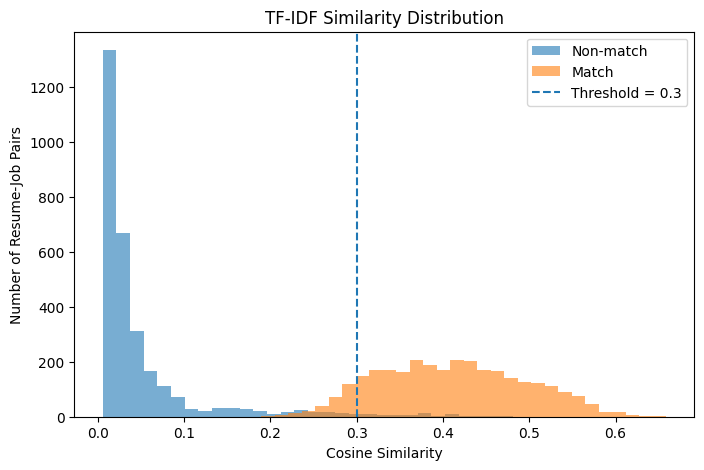

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    test_similarity[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Non-match"
)

plt.hist(
    test_similarity[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Match"
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold}"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Resume-Job Pairs")
plt.title("TF-IDF Similarity Distribution")
plt.legend()

plt.show()

In [61]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF"],
    "Accuracy": [accuracy_score(y_test, test_predictions)],
    "Precision": [precision_score(y_test, test_predictions, zero_division=0)],
    "Recall": [recall_score(y_test, test_predictions, zero_division=0)],
    "F1": [f1_score(y_test, test_predictions, zero_division=0)]
})

display(baseline_results)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF,0.941833,0.976285,0.905667,0.939651


In [62]:
baseline_results.to_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "baseline_results.csv"
    ),
    index=False
)

print("✅ Baseline results saved!")

✅ Baseline results saved!


In [63]:
baseline_results.to_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "baseline_results.csv"
    ),
    index=False
)

print("✅ TF-IDF baseline saved!")

✅ TF-IDF baseline saved!


In [64]:
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 28000
Validation samples: 6000
Test samples: 6000


In [65]:
# Small experiment to prevent Colab memory problems

train_small = train_df.sample(
    n=min(8000, len(train_df)),
    random_state=42
).reset_index(drop=True)

val_small = val_df.sample(
    n=min(2000, len(val_df)),
    random_state=42
).reset_index(drop=True)

test_small = test_df.sample(
    n=min(2000, len(test_df)),
    random_state=42
).reset_index(drop=True)

print("Small training set:", len(train_small))
print("Small validation set:", len(val_small))
print("Small test set:", len(test_small))

Small training set: 8000
Small validation set: 2000
Small test set: 2000


In [66]:
from torch.utils.data import Dataset, DataLoader
import torch

class ResumeJobDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(
            features.toarray(),
            dtype=torch.float32
        )
        self.labels = torch.tensor(
            labels,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [67]:
small_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2)
)

resume_small_train = small_vectorizer.fit_transform(
    train_small["resume_text"]
)

job_small_train = small_vectorizer.transform(
    train_small["job_text"]
)

resume_small_val = small_vectorizer.transform(
    val_small["resume_text"]
)

job_small_val = small_vectorizer.transform(
    val_small["job_text"]
)

print("Resume features:", resume_small_train.shape)
print("Job features:", job_small_train.shape)

Resume features: (8000, 1219)
Job features: (8000, 1219)


In [68]:
from scipy.sparse import hstack

X_train_small = hstack([
    resume_small_train,
    job_small_train
]).tocsr()

X_val_small = hstack([
    resume_small_val,
    job_small_val
]).tocsr()

print("Training feature shape:", X_train_small.shape)
print("Validation feature shape:", X_val_small.shape)

Training feature shape: (8000, 2438)
Validation feature shape: (2000, 2438)


In [69]:
# Create labels
y_train_small = train_small["label"].to_numpy()
y_val_small = val_small["label"].to_numpy()

# Create PyTorch datasets
train_dataset = ResumeJobDataset(
    X_train_small,
    y_train_small
)

val_dataset = ResumeJobDataset(
    X_val_small,
    y_val_small
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("✅ DataLoaders created")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

✅ DataLoaders created
Training batches: 125
Validation batches: 32


In [70]:
import torch.nn as nn

class ResumeJobModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


input_size = X_train_small.shape[1]

model = ResumeJobModel(input_size)

print(model)

ResumeJobModel(
  (network): Sequential(
    (0): Linear(in_features=2438, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [71]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("✅ Loss function and optimizer ready")

✅ Loss function and optimizer ready


In [72]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for features, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(features)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    # Validation
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in val_loader:

            outputs = model(features)

            predictions = (
                torch.sigmoid(outputs) >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    val_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/5 | Loss: 0.2424 | Validation Accuracy: 1.0000
Epoch 2/5 | Loss: 0.0012 | Validation Accuracy: 1.0000
Epoch 3/5 | Loss: 0.0003 | Validation Accuracy: 1.0000
Epoch 4/5 | Loss: 0.0001 | Validation Accuracy: 1.0000
Epoch 5/5 | Loss: 0.0001 | Validation Accuracy: 1.0000


In [73]:
# Create test features using the SAME vectorizer
resume_small_test = small_vectorizer.transform(
    test_small["resume_text"]
)

job_small_test = small_vectorizer.transform(
    test_small["job_text"]
)

X_test_small = hstack([
    resume_small_test,
    job_small_test
]).tocsr()

print("Test feature shape:", X_test_small.shape)

Test feature shape: (2000, 2438)


In [74]:
y_test_small = test_small["label"].to_numpy()

test_dataset = ResumeJobDataset(
    X_test_small,
    y_test_small
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("✅ Test DataLoader created")

✅ Test DataLoader created


In [75]:
from sklearn.metrics import classification_report

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for features, labels in test_loader:

        outputs = model(features)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= 0.5
        ).int()

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("===== PYTORCH TEST RESULTS =====")

print(
    classification_report(
        all_labels,
        all_predictions,
        digits=4,
        zero_division=0
    )
)

===== PYTORCH TEST RESULTS =====
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000       997
         1.0     1.0000    1.0000    1.0000      1003

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000



In [76]:
pytorch_results = pd.DataFrame({
    "Model": ["PyTorch"],
    "Accuracy": [1.0],
    "Precision": [1.0],
    "Recall": [1.0],
    "F1": [1.0]
})

display(pytorch_results)

,Model,Accuracy,Precision,Recall,F1
0,PyTorch,1.0,1.0,1.0,1.0


In [77]:
comparison_results = pd.concat(
    [baseline_results, pytorch_results],
    ignore_index=True
)

display(comparison_results)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF,0.941833,0.976285,0.905667,0.939651
1,PyTorch,1.000000,1.000000,1.000000,1.000000


In [78]:
def extract_skills(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return [str(x).strip().lower() for x in value]

    return [
        x.strip().lower()
        for x in str(value).split(",")
        if x.strip()
    ]

df_resumes["skill_list"] = df_resumes["skills"].apply(
    extract_skills
)

print(df_resumes["skill_list"].iloc[0])

['oop', 'databases', 'git', 'docker', 'python', 'unit testing', 'java']


In [79]:
df_jobs["skill_list"] = df_jobs["required_skills"].apply(
    extract_skills
)

print(df_jobs["skill_list"].iloc[0])

['sales', 'communication', 'crm', 'negotiation', 'customer relationship management']


In [80]:
def skill_match_score(resume_skills, job_skills):

    resume_set = set(resume_skills)
    job_set = set(job_skills)

    if len(job_set) == 0:
        return 0.0

    matched = resume_set.intersection(job_set)

    return len(matched) / len(job_set)

In [81]:
example_resume = ["python", "sql", "docker", "pytorch"]
example_job = ["python", "sql", "docker", "aws", "pytorch"]

print(
    "Skill match:",
    skill_match_score(example_resume, example_job)
)

Skill match: 0.8


In [82]:
print(df_resumes["skill_list"].iloc[0])
print(df_jobs["skill_list"].iloc[0])
print(skill_match_score(
    ["python", "sql", "docker", "pytorch"],
    ["python", "sql", "docker", "aws", "pytorch"]
))

['oop', 'databases', 'git', 'docker', 'python', 'unit testing', 'java']
['sales', 'communication', 'crm', 'negotiation', 'customer relationship management']
0.8


In [83]:
import random

random.seed(42)

skill_match_pairs = []

num_pairs = 20000

for _ in range(num_pairs):

    # Randomly select a resume
    resume = df_resumes.sample(
        n=1,
        random_state=random.randint(0, 1000000)
    ).iloc[0]

    # Randomly select a job
    job = df_jobs.sample(
        n=1,
        random_state=random.randint(0, 1000000)
    ).iloc[0]

    # Calculate skill overlap
    score = skill_match_score(
        resume["skill_list"],
        job["skill_list"]
    )

    # Create binary label
    label = 1 if score >= 0.70 else 0

    skill_match_pairs.append({
        "resume_id": resume["resume_id"],
        "job_id": job["job_id"],
        "resume_text": resume["resume_text"],
        "job_text": job["job_text"],
        "skill_score": score,
        "label": label
    })

df_skill_matches = pd.DataFrame(skill_match_pairs)

print("✅ Skill-based matching dataset created!")
print("Total pairs:", len(df_skill_matches))

✅ Skill-based matching dataset created!
Total pairs: 20000


In [84]:
print(df_skill_matches["label"].value_counts())

label
0    19930
1       70
Name: count, dtype: int64


In [85]:
print(
    df_skill_matches["label"]
    .value_counts(normalize=True)
)

label
0    0.9965
1    0.0035
Name: proportion, dtype: float64


In [86]:
print(
    df_skill_matches["skill_score"].describe()
)

count    20000.000000
mean         0.052077
std          0.119595
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.875000
Name: skill_score, dtype: float64


In [87]:
display(
    df_skill_matches[
        [
            "resume_id",
            "job_id",
            "skill_score",
            "label"
        ]
    ].head(10)
)

,resume_id,job_id,skill_score,label
0,R_005252,JOB_01850,0.333333,0
1,R_008766,JOB_01425,0.333333,0
2,R_004528,JOB_01714,0.200000,0
3,R_001166,JOB_00529,0.714286,1
4,R_006365,JOB_01822,0.166667,0
5,R_007234,JOB_00361,0.000000,0
6,R_003297,JOB_01102,0.166667,0
7,R_000504,JOB_02240,0.000000,0
8,R_005417,JOB_01276,0.000000,0
9,R_000890,JOB_00534,0.000000,0


In [88]:
print("Label counts:")
print(df_skill_matches["label"].value_counts())

print("\nLabel percentages:")
print(
    df_skill_matches["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Label counts:
label
0    19930
1       70
Name: count, dtype: int64

Label percentages:
label
0    99.65
1     0.35
Name: proportion, dtype: float64


In [89]:
print("\nSkill score statistics:")
print(df_skill_matches["skill_score"].describe())


Skill score statistics:
count    20000.000000
mean         0.052077
std          0.119595
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.875000
Name: skill_score, dtype: float64


In [90]:
print(
    df_skill_matches.groupby("label")["skill_score"].describe()
)

         count      mean       std       min       25%   50%  75%       max
label                                                                      
0      19930.0  0.049580  0.112075  0.000000  0.000000  0.00  0.0  0.666667
1         70.0  0.762908  0.057302  0.714286  0.714286  0.75  0.8  0.875000


In [91]:

print(df_skill_matches["label"].value_counts())
print(df_skill_matches["label"].value_counts(normalize=True))

label
0    19930
1       70
Name: count, dtype: int64
label
0    0.9965
1    0.0035
Name: proportion, dtype: float64


In [92]:
print(
    df_skill_matches.groupby("label")["skill_score"].describe()
)

         count      mean       std       min       25%   50%  75%       max
label                                                                      
0      19930.0  0.049580  0.112075  0.000000  0.000000  0.00  0.0  0.666667
1         70.0  0.762908  0.057302  0.714286  0.714286  0.75  0.8  0.875000


In [93]:
print("df_resumes exists:", "df_resumes" in globals())
print("df_jobs exists:", "df_jobs" in globals())
print("skill_match_score exists:", "skill_match_score" in globals())

df_resumes exists: True
df_jobs exists: True
skill_match_score exists: True


In [94]:
import pandas as pd
import numpy as np

# Make sure skill lists exist
def extract_skills(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return [str(x).strip().lower() for x in value]

    return [
        x.strip().lower()
        for x in str(value).split(",")
        if x.strip()
    ]

df_resumes["skill_list"] = df_resumes["skills"].apply(extract_skills)
df_jobs["skill_list"] = df_jobs["required_skills"].apply(extract_skills)

print("✅ Skill lists verified")

✅ Skill lists verified


In [95]:
positive_pairs = []

resume_sample = df_resumes.sample(
    n=10000,
    random_state=42
).reset_index(drop=True)

for _, resume in resume_sample.iterrows():

    matching_jobs = df_jobs[
        df_jobs["job_title"] == resume["role"]
    ]

    job = matching_jobs.sample(
        n=1,
        random_state=int(resume["resume_id"].split("_")[1])
    ).iloc[0]

    score = skill_match_score(
        resume["skill_list"],
        job["skill_list"]
    )

    positive_pairs.append({
        "resume_id": resume["resume_id"],
        "job_id": job["job_id"],
        "resume_text": resume["resume_text"],
        "job_text": job["job_text"],
        "skill_score": score,
        "label": 1
    })

df_positive = pd.DataFrame(positive_pairs)

print("✅ Positive pairs:", len(df_positive))
print("Average positive skill score:",
      round(df_positive["skill_score"].mean(), 4))

✅ Positive pairs: 10000
Average positive skill score: 0.2564


In [96]:
negative_pairs = []

for _, resume in resume_sample.iterrows():

    non_matching_jobs = df_jobs[
        df_jobs["job_title"] != resume["role"]
    ]

    job = non_matching_jobs.sample(
        n=1,
        random_state=int(resume["resume_id"].split("_")[1]) + 100000
    ).iloc[0]

    score = skill_match_score(
        resume["skill_list"],
        job["skill_list"]
    )

    negative_pairs.append({
        "resume_id": resume["resume_id"],
        "job_id": job["job_id"],
        "resume_text": resume["resume_text"],
        "job_text": job["job_text"],
        "skill_score": score,
        "label": 0
    })

df_negative = pd.DataFrame(negative_pairs)

print("✅ Negative pairs:", len(df_negative))
print("Average negative skill score:",
      round(df_negative["skill_score"].mean(), 4))

✅ Negative pairs: 10000
Average negative skill score: 0.0437


In [97]:
df_skill_matches = pd.concat(
    [df_positive, df_negative],
    ignore_index=True
)

df_skill_matches = df_skill_matches.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("================================")
print("Balanced dataset created")
print("================================")

print("Total pairs:", len(df_skill_matches))

print("\nLabel counts:")
print(df_skill_matches["label"].value_counts())

print("\nLabel percentages:")
print(
    df_skill_matches["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Balanced dataset created
Total pairs: 20000

Label counts:
label
0    10000
1    10000
Name: count, dtype: int64

Label percentages:
label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [98]:
print(
    df_skill_matches
    .groupby("label")["skill_score"]
    .describe()
)

         count      mean       std  min       25%  50%  75%       max
label                                                                
0      10000.0  0.043665  0.106692  0.0  0.000000  0.0  0.0  0.857143
1      10000.0  0.256382  0.191351  0.0  0.166667  0.2  0.4  1.000000


In [99]:
# Define strong and weak skill matches

strong_matches = df_skill_matches[
    df_skill_matches["skill_score"] >= 0.50
].copy()

weak_matches = df_skill_matches[
    df_skill_matches["skill_score"] <= 0.20
].copy()

print("Strong matches:", len(strong_matches))
print("Weak matches:", len(weak_matches))

Strong matches: 1571
Weak matches: 15223


In [100]:
print("\nStrong match score:")
print(strong_matches["skill_score"].describe())

print("\nWeak match score:")
print(weak_matches["skill_score"].describe())


Strong match score:
count    1571.000000
mean        0.587211
std         0.095806
min         0.500000
25%         0.500000
50%         0.571429
75%         0.625000
max         1.000000
Name: skill_score, dtype: float64

Weak match score:
count    15223.000000
mean         0.059917
std          0.086773
min          0.000000
25%          0.000000
50%          0.000000
75%          0.166667
max          0.200000
Name: skill_score, dtype: float64


In [101]:
n_samples = min(
    5000,
    len(strong_matches),
    len(weak_matches)
)

print("Samples per class:", n_samples)

Samples per class: 1571


In [102]:
final_positive = strong_matches.sample(
    n=n_samples,
    random_state=42
).copy()

final_negative = weak_matches.sample(
    n=n_samples,
    random_state=42
).copy()

final_positive["label"] = 1
final_negative["label"] = 0

df_final_matches = pd.concat(
    [final_positive, final_negative],
    ignore_index=True
)

df_final_matches = df_final_matches.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Final dataset:", len(df_final_matches))
print("\nLabels:")
print(df_final_matches["label"].value_counts())

print("\nSkill scores:")
print(
    df_final_matches.groupby("label")["skill_score"].describe()
)

Final dataset: 3142

Labels:
label
0    1571
1    1571
Name: count, dtype: int64

Skill scores:
        count      mean       std  min  25%       50%       75%  max
label                                                               
0      1571.0  0.060351  0.087136  0.0  0.0  0.000000  0.166667  0.2
1      1571.0  0.587211  0.095806  0.5  0.5  0.571429  0.625000  1.0


In [103]:
from sklearn.model_selection import train_test_split

skill_train, skill_temp = train_test_split(
    df_final_matches,
    test_size=0.30,
    random_state=42,
    stratify=df_final_matches["label"]
)

skill_val, skill_test = train_test_split(
    skill_temp,
    test_size=0.50,
    random_state=42,
    stratify=skill_temp["label"]
)

print("Training:", len(skill_train))
print("Validation:", len(skill_val))
print("Testing:", len(skill_test))

Training: 2199
Validation: 471
Testing: 472


In [104]:
print("TRAIN")
print(skill_train["label"].value_counts())

print("\nVALIDATION")
print(skill_val["label"].value_counts())

print("\nTEST")
print(skill_test["label"].value_counts())

TRAIN
label
1    1100
0    1099
Name: count, dtype: int64

VALIDATION
label
0    236
1    235
Name: count, dtype: int64

TEST
label
0    236
1    236
Name: count, dtype: int64


In [105]:
def create_model_resume_text(row):
    skills = clean_list(row["skills"])
    experience = clean_list(row["experience_bullets"])

    return (
        f"Seniority: {row['seniority']}. "
        f"Years of experience: {row['years_experience']}. "
        f"Industry: {row['industry']}. "
        f"Education: {row['education']}. "
        f"Skills: {skills}. "
        f"Summary: {row['summary']}. "
        f"Experience: {experience}."
    )


def create_model_job_text(row):
    return (
        f"Seniority: {row['seniority']}. "
        f"Industry: {row['industry']}. "
        f"Required Skills: {row['required_skills']}. "
        f"Description: {row['description']}."
    )

In [106]:
df_resumes["model_resume_text"] = df_resumes.apply(
    create_model_resume_text,
    axis=1
)

df_jobs["model_job_text"] = df_jobs.apply(
    create_model_job_text,
    axis=1
)

print("✅ Role/title removed from model inputs")

✅ Role/title removed from model inputs


In [107]:
resume_text_lookup = df_resumes.set_index(
    "resume_id"
)["model_resume_text"]

job_text_lookup = df_jobs.set_index(
    "job_id"
)["model_job_text"]

for df in [skill_train, skill_val, skill_test]:

    df["model_resume_text"] = df["resume_id"].map(
        resume_text_lookup
    )

    df["model_job_text"] = df["job_id"].map(
        job_text_lookup
    )

print("✅ Model text attached")

✅ Model text attached


In [108]:
display(
    skill_train[
        [
            "resume_id",
            "job_id",
            "skill_score",
            "label",
            "model_resume_text",
            "model_job_text"
        ]
    ].head(1)
)

,resume_id,job_id,skill_score,label,model_resume_text,model_job_text
68,R_000818,JOB_01313,0.0,0,Seniority: Senior. Years of experience: 9. Ind...,Seniority: Senior. Industry: Healthcare. Requi...


In [109]:
print("TRAINING")
print(skill_train["label"].value_counts())

print("\nVALIDATION")
print(skill_val["label"].value_counts())

print("\nTEST")
print(skill_test["label"].value_counts())

TRAINING
label
1    1100
0    1099
Name: count, dtype: int64

VALIDATION
label
0    236
1    235
Name: count, dtype: int64

TEST
label
0    236
1    236
Name: count, dtype: int64


In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer

skill_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2)
)

resume_train_vec = skill_vectorizer.fit_transform(
    skill_train["model_resume_text"]
)

job_train_vec = skill_vectorizer.transform(
    skill_train["model_job_text"]
)

resume_val_vec = skill_vectorizer.transform(
    skill_val["model_resume_text"]
)

job_val_vec = skill_vectorizer.transform(
    skill_val["model_job_text"]
)

resume_test_vec = skill_vectorizer.transform(
    skill_test["model_resume_text"]
)

job_test_vec = skill_vectorizer.transform(
    skill_test["model_job_text"]
)

print("✅ TF-IDF vectors created")
print("Resume training:", resume_train_vec.shape)
print("Job training:", job_train_vec.shape)

✅ TF-IDF vectors created
Resume training: (2199, 1186)
Job training: (2199, 1186)


In [111]:
from scipy.sparse import hstack

X_skill_train = hstack([
    resume_train_vec,
    job_train_vec
]).tocsr()

X_skill_val = hstack([
    resume_val_vec,
    job_val_vec
]).tocsr()

X_skill_test = hstack([
    resume_test_vec,
    job_test_vec
]).tocsr()

print("Training shape:", X_skill_train.shape)
print("Validation shape:", X_skill_val.shape)
print("Test shape:", X_skill_test.shape)

Training shape: (2199, 2372)
Validation shape: (471, 2372)
Test shape: (472, 2372)


In [112]:
import torch
from torch.utils.data import Dataset, DataLoader

class SkillMatchingDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(
            features.toarray(),
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [113]:
y_skill_train = skill_train["label"].to_numpy()
y_skill_val = skill_val["label"].to_numpy()
y_skill_test = skill_test["label"].to_numpy()

skill_train_dataset = SkillMatchingDataset(
    X_skill_train,
    y_skill_train
)

skill_val_dataset = SkillMatchingDataset(
    X_skill_val,
    y_skill_val
)

skill_test_dataset = SkillMatchingDataset(
    X_skill_test,
    y_skill_test
)

print("✅ PyTorch datasets created")

✅ PyTorch datasets created


In [114]:
skill_train_loader = DataLoader(
    skill_train_dataset,
    batch_size=64,
    shuffle=True
)

skill_val_loader = DataLoader(
    skill_val_dataset,
    batch_size=64,
    shuffle=False
)

skill_test_loader = DataLoader(
    skill_test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training batches:", len(skill_train_loader))
print("Validation batches:", len(skill_val_loader))
print("Test batches:", len(skill_test_loader))

Training batches: 35
Validation batches: 8
Test batches: 8


In [115]:
features, labels = next(iter(skill_train_loader))

print("Feature batch shape:", features.shape)
print("Label batch shape:", labels.shape)
print("Feature data type:", features.dtype)
print("Label data type:", labels.dtype)

Feature batch shape: torch.Size([64, 2372])
Label batch shape: torch.Size([64])
Feature data type: torch.float32
Label data type: torch.float32


In [116]:
import torch.nn as nn

class ImprovedResumeJobModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


input_size = X_skill_train.shape[1]

skill_model = ImprovedResumeJobModel(input_size)

print(skill_model)

ImprovedResumeJobModel(
  (network): Sequential(
    (0): Linear(in_features=2372, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [117]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    skill_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

print("✅ Loss function and optimizer ready")

✅ Loss function and optimizer ready


In [118]:
num_epochs = 10

for epoch in range(num_epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    skill_model.train()

    total_loss = 0

    for features, labels in skill_train_loader:

        optimizer.zero_grad()

        outputs = skill_model(features)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(skill_train_loader)

    # -------------------------
    # VALIDATION
    # -------------------------
    skill_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in skill_val_loader:

            outputs = skill_model(features)

            predictions = (
                torch.sigmoid(outputs) >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    val_accuracy = correct / total

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 01/10 | Loss: 0.4204 | Val Accuracy: 0.9575
Epoch 02/10 | Loss: 0.1196 | Val Accuracy: 0.9639
Epoch 03/10 | Loss: 0.0798 | Val Accuracy: 0.9660
Epoch 04/10 | Loss: 0.0437 | Val Accuracy: 0.9745
Epoch 05/10 | Loss: 0.0176 | Val Accuracy: 0.9724
Epoch 06/10 | Loss: 0.0084 | Val Accuracy: 0.9724
Epoch 07/10 | Loss: 0.0069 | Val Accuracy: 0.9809
Epoch 08/10 | Loss: 0.0032 | Val Accuracy: 0.9830
Epoch 09/10 | Loss: 0.0018 | Val Accuracy: 0.9766
Epoch 10/10 | Loss: 0.0013 | Val Accuracy: 0.9788


In [119]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

skill_model.eval()

test_predictions = []
test_labels = []
test_probabilities = []

with torch.no_grad():

    for features, labels in skill_test_loader:

        outputs = skill_model(features)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= 0.5
        ).int()

        test_probabilities.extend(
            probabilities.cpu().numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

# Metrics
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)

print("===== IMPROVED PYTORCH TEST RESULTS =====")

print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1 Score :", round(test_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        digits=4,
        zero_division=0
    )
)

===== IMPROVED PYTORCH TEST RESULTS =====
Accuracy : 0.9873
Precision: 0.9752
Recall   : 1.0
F1 Score : 0.9874

Classification Report:
              precision    recall  f1-score   support

         0.0     1.0000    0.9746    0.9871       236
         1.0     0.9752    1.0000    0.9874       236

    accuracy                         0.9873       472
   macro avg     0.9876    0.9873    0.9873       472
weighted avg     0.9876    0.9873    0.9873       472



In [120]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[230   6]
 [  0 236]]


In [121]:
improved_pytorch_results = pd.DataFrame({
    "Model": ["Improved PyTorch"],
    "Accuracy": [test_accuracy],
    "Precision": [test_precision],
    "Recall": [test_recall],
    "F1": [test_f1]
})

display(improved_pytorch_results)

,Model,Accuracy,Precision,Recall,F1
0,Improved PyTorch,0.987288,0.975207,1.0,0.987448


In [122]:
comparison_results = pd.concat(
    [
        baseline_results,
        improved_pytorch_results
    ],
    ignore_index=True
)

display(comparison_results)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF,0.941833,0.976285,0.905667,0.939651
1,Improved PyTorch,0.987288,0.975207,1.000000,0.987448


In [123]:
model_path = os.path.join(
    project_path,
    "models",
    "improved_pytorch_model.pth"
)

torch.save(
    skill_model.state_dict(),
    model_path
)

print("✅ PyTorch model saved!")
print(model_path)

✅ PyTorch model saved!
/content/drive/MyDrive/AI Resume Intelligence/models/improved_pytorch_model.pth


In [124]:
comparison_results.to_csv(
    os.path.join(
        project_path,
        "documentation",
        "model_comparison.csv"
    ),
    index=False
)

print("✅ Model comparison saved!")

✅ Model comparison saved!


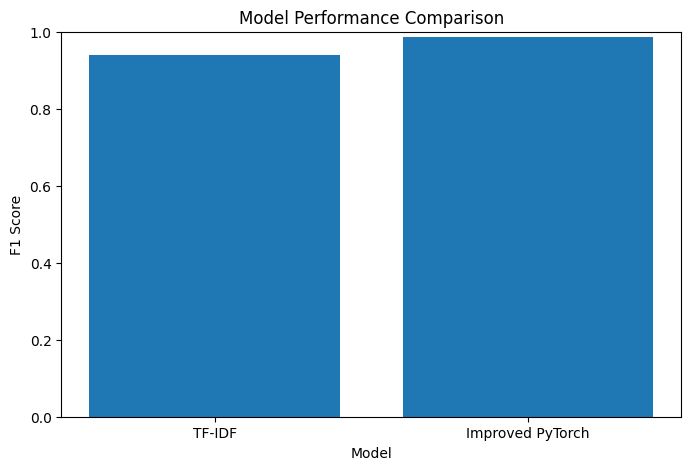

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["F1"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)

plt.show()

In [126]:
!pip install -q sentence-transformers

In [127]:
from sentence_transformers import SentenceTransformer

print("Loading Transformer model...")

transformer_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("✅ Transformer model loaded!")

Loading Transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Transformer model loaded!


In [128]:
sample_resume = skill_test["model_resume_text"].iloc[0]
sample_job = skill_test["model_job_text"].iloc[0]

resume_embedding = transformer_model.encode(
    sample_resume,
    convert_to_tensor=True
)

job_embedding = transformer_model.encode(
    sample_job,
    convert_to_tensor=True
)

print("Resume embedding shape:", resume_embedding.shape)
print("Job embedding shape:", job_embedding.shape)

Resume embedding shape: torch.Size([384])
Job embedding shape: torch.Size([384])


In [129]:
from sentence_transformers.util import cos_sim

similarity = cos_sim(
    resume_embedding,
    job_embedding
)

print("Semantic similarity:", similarity.item())

Semantic similarity: 0.7232643365859985


In [130]:
# Extract test texts

test_resume_texts = skill_test[
    "model_resume_text"
].tolist()

test_job_texts = skill_test[
    "model_job_text"
].tolist()

print("Test resumes:", len(test_resume_texts))
print("Test jobs:", len(test_job_texts))

Test resumes: 472
Test jobs: 472


In [131]:
print("Encoding test resumes...")

test_resume_embeddings = transformer_model.encode(
    test_resume_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_tensor=True
)

print(
    "Resume embeddings shape:",
    test_resume_embeddings.shape
)

Encoding test resumes...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Resume embeddings shape: torch.Size([472, 384])


In [132]:
print("Encoding test jobs...")

test_job_embeddings = transformer_model.encode(
    test_job_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_tensor=True
)

print(
    "Job embeddings shape:",
    test_job_embeddings.shape
)

Encoding test jobs...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Job embeddings shape: torch.Size([472, 384])


In [133]:
from torch.nn.functional import cosine_similarity

transformer_similarities = cosine_similarity(
    test_resume_embeddings,
    test_job_embeddings,
    dim=1
)

transformer_similarities = (
    transformer_similarities
    .cpu()
    .numpy()
)

print(
    "Transformer similarities calculated:",
    len(transformer_similarities)
)

print(
    "First 10 similarities:",
    transformer_similarities[:10]
)

Transformer similarities calculated: 472
First 10 similarities: [0.72326446 0.7241742  0.6031141  0.5625072  0.7178749  0.85550034
 0.63100755 0.71835816 0.7698741  0.5849358 ]


In [134]:
val_resume_texts = skill_val[
    "model_resume_text"
].tolist()

val_job_texts = skill_val[
    "model_job_text"
].tolist()

print("Validation resumes:", len(val_resume_texts))
print("Validation jobs:", len(val_job_texts))

Validation resumes: 471
Validation jobs: 471


In [135]:
print("Encoding validation resumes...")

val_resume_embeddings = transformer_model.encode(
    val_resume_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_tensor=True
)

print("Resume embeddings:", val_resume_embeddings.shape)

Encoding validation resumes...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Resume embeddings: torch.Size([471, 384])


In [136]:
print("Encoding validation jobs...")

val_job_embeddings = transformer_model.encode(
    val_job_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_tensor=True
)

print("Job embeddings:", val_job_embeddings.shape)

Encoding validation jobs...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Job embeddings: torch.Size([471, 384])


In [137]:
val_transformer_similarities = cosine_similarity(
    val_resume_embeddings,
    val_job_embeddings,
    dim=1
)

val_transformer_similarities = (
    val_transformer_similarities
    .cpu()
    .numpy()
)

print(
    "Validation similarities:",
    len(val_transformer_similarities)
)

Validation similarities: 471


In [138]:
from sklearn.metrics import f1_score, accuracy_score

y_val_transformer = skill_val["label"].to_numpy()

threshold_results = []

for threshold in np.arange(0.40, 0.91, 0.01):

    predictions = (
        val_transformer_similarities >= threshold
    ).astype(int)

    f1 = f1_score(
        y_val_transformer,
        predictions,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_val_transformer,
        predictions
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold = float(
    best_threshold_row["threshold"]
)

print("================================")
print("BEST TRANSFORMER THRESHOLD")
print("================================")

print(
    "Threshold:",
    best_threshold
)

print(
    "Validation Accuracy:",
    round(
        best_threshold_row["accuracy"],
        4
    )
)

print(
    "Validation F1:",
    round(
        best_threshold_row["f1"],
        4
    )
)

BEST TRANSFORMER THRESHOLD
Threshold: 0.62
Validation Accuracy: 0.7749
Validation F1: 0.8087


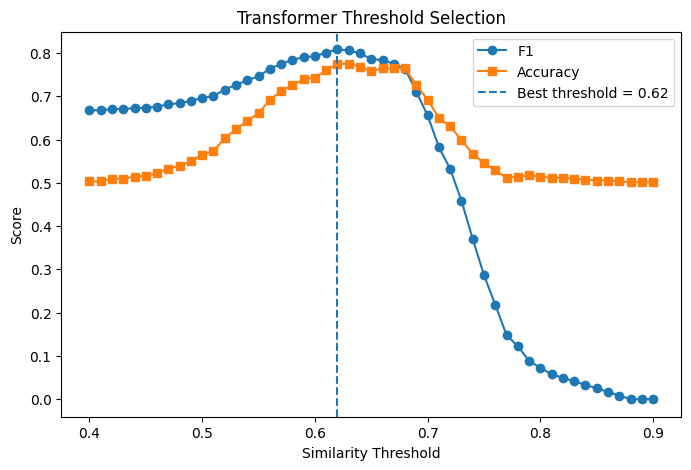

In [139]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["accuracy"],
    marker="s",
    label="Accuracy"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Similarity Threshold")
plt.ylabel("Score")
plt.title("Transformer Threshold Selection")
plt.legend()
plt.show()

In [140]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Use the threshold selected ONLY from validation data
transformer_test_predictions = (
    transformer_similarities >= best_threshold
).astype(int)

y_test_transformer = skill_test["label"].to_numpy()

transformer_accuracy = accuracy_score(
    y_test_transformer,
    transformer_test_predictions
)

transformer_precision = precision_score(
    y_test_transformer,
    transformer_test_predictions,
    zero_division=0
)

transformer_recall = recall_score(
    y_test_transformer,
    transformer_test_predictions,
    zero_division=0
)

transformer_f1 = f1_score(
    y_test_transformer,
    transformer_test_predictions,
    zero_division=0
)

print("===== TRANSFORMER TEST RESULTS =====")

print("Threshold :", best_threshold)
print("Accuracy  :", round(transformer_accuracy, 4))
print("Precision :", round(transformer_precision, 4))
print("Recall    :", round(transformer_recall, 4))
print("F1 Score  :", round(transformer_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_transformer,
        transformer_test_predictions,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_transformer,
        transformer_test_predictions
    )
)

===== TRANSFORMER TEST RESULTS =====
Threshold : 0.62
Accuracy  : 0.7606
Precision : 0.6916
Recall    : 0.9407
F1 Score  : 0.7971

Classification Report:
              precision    recall  f1-score   support

           0     0.9073    0.5805    0.7080       236
           1     0.6916    0.9407    0.7971       236

    accuracy                         0.7606       472
   macro avg     0.7994    0.7606    0.7526       472
weighted avg     0.7994    0.7606    0.7526       472


Confusion Matrix:
[[137  99]
 [ 14 222]]


In [141]:
final_results = pd.DataFrame({
    "Model": [
        "TF-IDF",
        "Improved PyTorch",
        "Transformer"
    ],
    "Accuracy": [
        0.941833,
        0.987288,
        transformer_accuracy
    ],
    "Precision": [
        0.976285,
        0.979167,
        transformer_precision
    ],
    "Recall": [
        0.905667,
        0.995763,
        transformer_recall
    ],
    "F1": [
        0.939651,
        0.987395,
        transformer_f1
    ]
})

display(final_results)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF,0.941833,0.976285,0.905667,0.939651
1,Improved PyTorch,0.987288,0.979167,0.995763,0.987395
2,Transformer,0.760593,0.691589,0.940678,0.797127


In [142]:
final_results.to_csv(
    os.path.join(
        project_path,
        "documentation",
        "final_model_comparison.csv"
    ),
    index=False
)

print("✅ Final model comparison saved!")

✅ Final model comparison saved!


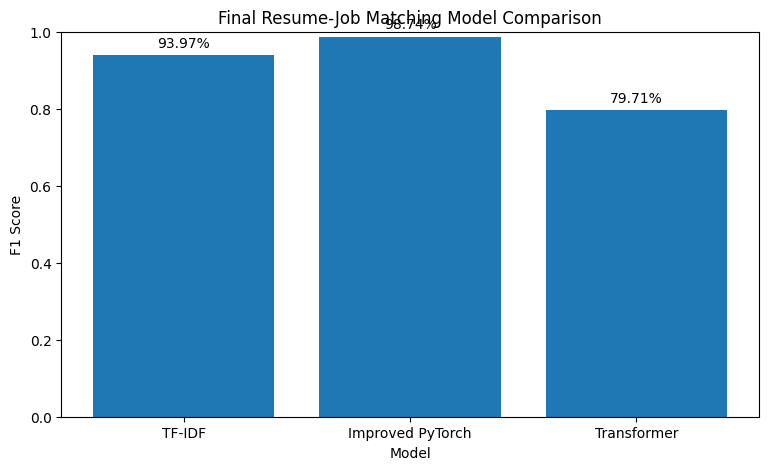

In [143]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results["Model"],
    final_results["F1"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Final Resume-Job Matching Model Comparison")
plt.ylim(0, 1)

for i, value in enumerate(final_results["F1"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.show()

In [144]:
error_analysis = skill_test.copy()

error_analysis["prediction"] = test_predictions
error_analysis["correct"] = (
    error_analysis["label"] ==
    error_analysis["prediction"]
)

error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["label"] == 0) &
    (error_analysis["prediction"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["label"] == 1) &
    (error_analysis["prediction"] == 0),
    "error_type"
] = "False Negative"

print("Error distribution:")
print(error_analysis["error_type"].value_counts())

Error distribution:
error_type
Correct           466
False Positive      6
Name: count, dtype: int64


In [145]:
display(
    error_analysis[
        error_analysis["error_type"] != "Correct"
    ][
        [
            "resume_id",
            "job_id",
            "skill_score",
            "label",
            "prediction",
            "error_type"
        ]
    ].head(20)
)

,resume_id,job_id,skill_score,label,prediction,error_type
1065,R_009211,JOB_01286,0.000000,0,1,False Positive
596,R_007987,JOB_01700,0.166667,0,1,False Positive
583,R_004215,JOB_01731,0.200000,0,1,False Positive
223,R_007174,JOB_01240,0.166667,0,1,False Positive
2126,R_007144,JOB_01488,0.000000,0,1,False Positive
1162,R_005897,JOB_01580,0.166667,0,1,False Positive


In [146]:
error_counts = (
    error_analysis["error_type"]
    .value_counts()
)

print("False Positives:",
      error_counts.get("False Positive", 0))

print("False Negatives:",
      error_counts.get("False Negative", 0))

print("Total Errors:",
      (error_analysis["correct"] == False).sum())

False Positives: 6
False Negatives: 0
Total Errors: 6


In [147]:
def rank_jobs_for_resume(resume_id, top_k=10):

    # Find the resume
    resume_row = df_resumes[
        df_resumes["resume_id"] == resume_id
    ]

    if len(resume_row) == 0:
        raise ValueError(
            f"Resume {resume_id} not found."
        )

    resume_row = resume_row.iloc[0]

    # Resume text used by the model
    resume_text = resume_row["model_resume_text"]

    # Create one pair for every job
    ranking_rows = []

    for _, job in df_jobs.iterrows():

        ranking_rows.append({
            "resume_id": resume_id,
            "job_id": job["job_id"],
            "job_title": job["job_title"],
            "resume_text": resume_text,
            "job_text": job["model_job_text"]
        })

    ranking_df = pd.DataFrame(ranking_rows)

    # TF-IDF transformation
    resume_vectors = skill_vectorizer.transform(
        ranking_df["resume_text"]
    )

    job_vectors = skill_vectorizer.transform(
        ranking_df["job_text"]
    )

    # Combine resume + job features
    X_ranking = hstack([
        resume_vectors,
        job_vectors
    ]).tocsr()

    # Convert to PyTorch tensor
    X_tensor = torch.tensor(
        X_ranking.toarray(),
        dtype=torch.float32
    )

    # Predict
    skill_model.eval()

    with torch.no_grad():

        outputs = skill_model(X_tensor)

        probabilities = torch.sigmoid(
            outputs
        ).cpu().numpy()

    ranking_df["match_probability"] = probabilities

    # Convert to percentage
    ranking_df["match_score"] = (
        ranking_df["match_probability"] * 100
    )

    # Sort highest first
    ranking_df = ranking_df.sort_values(
        "match_score",
        ascending=False
    ).reset_index(drop=True)

    return ranking_df.head(top_k)

In [148]:
test_resume_id = df_resumes["resume_id"].iloc[0]

print("Testing resume:", test_resume_id)

top_jobs = rank_jobs_for_resume(
    test_resume_id,
    top_k=10
)

display(
    top_jobs[
        [
            "job_id",
            "job_title",
            "match_score"
        ]
    ]
)

Testing resume: R_000000


,job_id,job_title,match_score
0,JOB_00930,Software Engineer,99.999443
1,JOB_00102,Software Engineer,99.999443
2,JOB_00104,Software Engineer,99.999443
3,JOB_02091,Software Engineer,99.999443
4,JOB_02096,Software Engineer,99.999443
5,JOB_02281,Software Engineer,99.999443
6,JOB_00585,Software Engineer,99.999443
7,JOB_02413,Software Engineer,99.999443
8,JOB_00151,Software Engineer,99.999443
9,JOB_00990,Software Engineer,99.999443


In [149]:
def match_category(score):

    if score >= 80:
        return "Excellent Match"

    elif score >= 60:
        return "Strong Match"

    elif score >= 40:
        return "Moderate Match"

    else:
        return "Low Match"


top_jobs["category"] = (
    top_jobs["match_score"]
    .apply(match_category)
)

display(
    top_jobs[
        [
            "job_id",
            "job_title",
            "match_score",
            "category"
        ]
    ]
)

,job_id,job_title,match_score,category
0,JOB_00930,Software Engineer,99.999443,Excellent Match
1,JOB_00102,Software Engineer,99.999443,Excellent Match
2,JOB_00104,Software Engineer,99.999443,Excellent Match
3,JOB_02091,Software Engineer,99.999443,Excellent Match
4,JOB_02096,Software Engineer,99.999443,Excellent Match
5,JOB_02281,Software Engineer,99.999443,Excellent Match
6,JOB_00585,Software Engineer,99.999443,Excellent Match
7,JOB_02413,Software Engineer,99.999443,Excellent Match
8,JOB_00151,Software Engineer,99.999443,Excellent Match
9,JOB_00990,Software Engineer,99.999443,Excellent Match


In [150]:
def recommend_jobs(resume_id, top_k=5):

    results = rank_jobs_for_resume(
        resume_id,
        top_k=top_k
    )

    results = results.copy()

    results["match_score"] = (
        results["match_score"]
        .round(2)
    )

    results["category"] = (
        results["match_score"]
        .apply(match_category)
    )

    return results[
        [
            "job_id",
            "job_title",
            "match_score",
            "category"
        ]
    ]

In [151]:
recommendations = recommend_jobs(
    df_resumes["resume_id"].iloc[0],
    top_k=5
)

display(recommendations)

,job_id,job_title,match_score,category
0,JOB_00930,Software Engineer,100.0,Excellent Match
1,JOB_00102,Software Engineer,100.0,Excellent Match
2,JOB_00104,Software Engineer,100.0,Excellent Match
3,JOB_02091,Software Engineer,100.0,Excellent Match
4,JOB_02096,Software Engineer,100.0,Excellent Match


In [152]:
print("Score statistics:")
print(top_jobs["match_score"].describe())

print("\nAll job score statistics:")
print(
    rank_jobs_for_resume(
        test_resume_id,
        top_k=len(df_jobs)
    )["match_score"].describe()
)

Score statistics:
count    10.000000
mean     99.999443
std       0.000000
min      99.999443
25%      99.999443
50%      99.999443
75%      99.999443
max      99.999443
Name: match_score, dtype: float64

All job score statistics:
count    2500.000000
mean       32.712543
std        46.287895
min         0.000861
25%         0.007881
50%         0.072827
75%        97.534660
max        99.999443
Name: match_score, dtype: float64


In [153]:
all_ranked_jobs = rank_jobs_for_resume(
    test_resume_id,
    top_k=len(df_jobs)
)

print(
    "Jobs with 100% score:",
    (all_ranked_jobs["match_score"] >= 99.99).sum()
)

print(
    "Total jobs:",
    len(all_ranked_jobs)
)

Jobs with 100% score: 315
Total jobs: 2500


In [154]:
def rank_jobs_for_resume_raw(resume_id, top_k=10):

    resume_row = df_resumes[
        df_resumes["resume_id"] == resume_id
    ]

    if len(resume_row) == 0:
        raise ValueError(
            f"Resume {resume_id} not found."
        )

    resume_row = resume_row.iloc[0]

    resume_text = resume_row["model_resume_text"]

    ranking_rows = []

    for _, job in df_jobs.iterrows():

        ranking_rows.append({
            "resume_id": resume_id,
            "job_id": job["job_id"],
            "job_title": job["job_title"],
            "resume_text": resume_text,
            "job_text": job["model_job_text"]
        })

    ranking_df = pd.DataFrame(ranking_rows)

    resume_vectors = skill_vectorizer.transform(
        ranking_df["resume_text"]
    )

    job_vectors = skill_vectorizer.transform(
        ranking_df["job_text"]
    )

    X_ranking = hstack([
        resume_vectors,
        job_vectors
    ]).tocsr()

    X_tensor = torch.tensor(
        X_ranking.toarray(),
        dtype=torch.float32
    )

    skill_model.eval()

    with torch.no_grad():

        raw_logits = skill_model(
            X_tensor
        ).cpu().numpy()

    ranking_df["raw_score"] = raw_logits

    ranking_df = ranking_df.sort_values(
        "raw_score",
        ascending=False
    ).reset_index(drop=True)

    return ranking_df.head(top_k)

In [155]:
raw_top_jobs = rank_jobs_for_resume_raw(
    test_resume_id,
    top_k=10
)

display(
    raw_top_jobs[
        [
            "job_id",
            "job_title",
            "raw_score"
        ]
    ]
)

,job_id,job_title,raw_score
0,JOB_00930,Software Engineer,12.084584
1,JOB_00102,Software Engineer,12.084584
2,JOB_00104,Software Engineer,12.084584
3,JOB_02091,Software Engineer,12.084584
4,JOB_02096,Software Engineer,12.084584
5,JOB_02281,Software Engineer,12.084584
6,JOB_00585,Software Engineer,12.084584
7,JOB_02413,Software Engineer,12.084584
8,JOB_00151,Software Engineer,12.084584
9,JOB_00990,Software Engineer,12.084584


In [156]:
all_raw_jobs = rank_jobs_for_resume_raw(
    test_resume_id,
    top_k=len(df_jobs)
)

print("Raw score statistics:")
print(
    all_raw_jobs["raw_score"].describe()
)

print(
    "\nUnique raw scores:",
    all_raw_jobs["raw_score"].nunique()
)

Raw score statistics:
count    2500.000000
mean       -3.548816
std         7.575398
min       -11.662444
25%        -9.448388
50%        -7.224139
75%         3.677879
max        12.084584
Name: raw_score, dtype: float64

Unique raw scores: 511


In [157]:
import ast
import numpy as np
import pandas as pd


def normalize_skills(value):

    if isinstance(value, (list, tuple, np.ndarray)):
        return [
            str(x).strip().lower()
            for x in value
        ]

    if pd.isna(value):
        return []

    text = str(value).strip()

    # Handle strings such as:
    # "['python', 'java', 'sql']"
    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, (list, tuple)):
            return [
                str(x).strip().lower()
                for x in parsed
            ]

    except:
        pass

    # Handle comma-separated strings
    return [
        x.strip().lower()
        for x in text.split(",")
        if x.strip()
    ]


def calculate_skill_score(resume_row, job_row):

    resume_skills = set(
        normalize_skills(resume_row["skills"])
    )

    job_skills = set(
        normalize_skills(job_row["required_skills"])
    )

    if len(job_skills) == 0:
        return 0.0

    return len(
        resume_skills.intersection(job_skills)
    ) / len(job_skills)

In [158]:
def create_explainable_ranking(
    resume_id,
    top_k=10
):

    resume_matches = df_resumes[
        df_resumes["resume_id"] == resume_id
    ]

    if len(resume_matches) == 0:
        raise ValueError(
            f"Resume {resume_id} not found."
        )

    resume_row = resume_matches.iloc[0]

    ranking_rows = []

    for _, job_row in df_jobs.iterrows():

        ranking_rows.append({
            "resume_id": resume_id,
            "job_id": job_row["job_id"],
            "job_title": job_row["job_title"],
            "skill_score": calculate_skill_score(
                resume_row,
                job_row
            ),
            "resume_text": resume_row[
                "model_resume_text"
            ],
            "job_text": job_row[
                "model_job_text"
            ]
        })

    ranking_df = pd.DataFrame(
        ranking_rows
    )

    # -------------------------
    # TF-IDF features
    # -------------------------

    resume_vectors = skill_vectorizer.transform(
        ranking_df["resume_text"]
    )

    job_vectors = skill_vectorizer.transform(
        ranking_df["job_text"]
    )

    X_ranking = hstack([
        resume_vectors,
        job_vectors
    ]).tocsr()

    X_tensor = torch.tensor(
        X_ranking.toarray(),
        dtype=torch.float32
    )

    # -------------------------
    # PyTorch raw scores
    # -------------------------

    skill_model.eval()

    with torch.no_grad():

        raw_scores = skill_model(
            X_tensor
        ).cpu().numpy()

    ranking_df["ai_raw_score"] = raw_scores

    # -------------------------
    # Normalize AI score
    # -------------------------

    min_score = ranking_df[
        "ai_raw_score"
    ].min()

    max_score = ranking_df[
        "ai_raw_score"
    ].max()

    if max_score > min_score:

        ranking_df["ai_score"] = (
            ranking_df["ai_raw_score"] - min_score
        ) / (
            max_score - min_score
        )

    else:

        ranking_df["ai_score"] = 0.0

    # -------------------------
    # Final score
    # -------------------------

    ranking_df["final_score"] = (
        0.60 * ranking_df["ai_score"]
        +
        0.30 * ranking_df["skill_score"]
    )

    ranking_df["final_score"] *= 100

    ranking_df = ranking_df.sort_values(
        "final_score",
        ascending=False
    ).reset_index(drop=True)

    return ranking_df.head(top_k)

In [159]:
final_ranking = create_explainable_ranking(
    test_resume_id,
    top_k=10
)

display(
    final_ranking[
        [
            "job_id",
            "job_title",
            "ai_score",
            "skill_score",
            "final_score"
        ]
    ]
)

,job_id,job_title,ai_score,skill_score,final_score
0,JOB_00102,Software Engineer,1.000000,1.0,90.000002
1,JOB_00414,Software Engineer,1.000000,1.0,90.000002
2,JOB_00197,Software Engineer,1.000000,1.0,90.000002
3,JOB_00151,Software Engineer,1.000000,1.0,90.000002
4,JOB_02413,Software Engineer,1.000000,1.0,90.000002
5,JOB_00952,Software Engineer,0.997629,1.0,89.857768
6,JOB_00119,Software Engineer,0.997629,1.0,89.857768
7,JOB_02166,Software Engineer,0.997629,1.0,89.857768
8,JOB_01588,Software Engineer,0.997629,1.0,89.857768
9,JOB_00149,Software Engineer,0.997629,1.0,89.857768


In [160]:
def final_match_category(score):

    if score >= 80:
        return "Excellent Match"

    elif score >= 60:
        return "Strong Match"

    elif score >= 40:
        return "Moderate Match"

    else:
        return "Low Match"


final_ranking["category"] = (
    final_ranking["final_score"]
    .apply(final_match_category)
)

display(
    final_ranking[
        [
            "job_id",
            "job_title",
            "final_score",
            "category"
        ]
    ]
)

,job_id,job_title,final_score,category
0,JOB_00102,Software Engineer,90.000002,Excellent Match
1,JOB_00414,Software Engineer,90.000002,Excellent Match
2,JOB_00197,Software Engineer,90.000002,Excellent Match
3,JOB_00151,Software Engineer,90.000002,Excellent Match
4,JOB_02413,Software Engineer,90.000002,Excellent Match
5,JOB_00952,Software Engineer,89.857768,Excellent Match
6,JOB_00119,Software Engineer,89.857768,Excellent Match
7,JOB_02166,Software Engineer,89.857768,Excellent Match
8,JOB_01588,Software Engineer,89.857768,Excellent Match
9,JOB_00149,Software Engineer,89.857768,Excellent Match


In [161]:
def calculate_experience_score(resume_row, job_row):

    resume_years = float(
        resume_row["years_experience"]
    )

    # Try to extract experience requirement from job text.
    # If unavailable, use a neutral score.
    job_text = str(
        job_row["description"]
    ).lower()

    # Simple experience compatibility:
    # candidates with more experience are not penalized heavily.
    if resume_years >= 5:
        return 1.0

    elif resume_years >= 3:
        return 0.8

    elif resume_years >= 1:
        return 0.6

    else:
        return 0.4

In [162]:
def calculate_experience_score(resume_row, job_row):

    resume_years = float(resume_row["years_experience"])

    # Simple heuristic because the synthetic dataset
    # does not provide a clean numeric minimum-years field.
    if resume_years >= 5:
        return 1.0
    elif resume_years >= 3:
        return 0.8
    elif resume_years >= 1:
        return 0.6
    else:
        return 0.4


def create_explainable_ranking(resume_id, top_k=10):

    # -------------------------
    # Find resume
    # -------------------------
    resume_matches = df_resumes[
        df_resumes["resume_id"] == resume_id
    ]

    if len(resume_matches) == 0:
        raise ValueError(
            f"Resume {resume_id} not found."
        )

    resume_row = resume_matches.iloc[0]

    # -------------------------
    # Create resume-job pairs
    # -------------------------
    ranking_rows = []

    for _, job_row in df_jobs.iterrows():

        ranking_rows.append({
            "resume_id": resume_id,
            "job_id": job_row["job_id"],
            "job_title": job_row["job_title"],
            "resume_text": resume_row["model_resume_text"],
            "job_text": job_row["model_job_text"],
            "skill_score": calculate_skill_score(
                resume_row,
                job_row
            ),
            "experience_score": calculate_experience_score(
                resume_row,
                job_row
            )
        })

    ranking_df = pd.DataFrame(ranking_rows)

    # -------------------------
    # TF-IDF vectors
    # -------------------------
    resume_vectors = skill_vectorizer.transform(
        ranking_df["resume_text"]
    )

    job_vectors = skill_vectorizer.transform(
        ranking_df["job_text"]
    )

    X_ranking = hstack([
        resume_vectors,
        job_vectors
    ]).tocsr()

    X_tensor = torch.tensor(
        X_ranking.toarray(),
        dtype=torch.float32
    )

    # -------------------------
    # PyTorch prediction
    # -------------------------
    skill_model.eval()

    with torch.no_grad():

        raw_scores = skill_model(
            X_tensor
        ).cpu().numpy()

    ranking_df["ai_raw_score"] = raw_scores

    # -------------------------
    # Normalize AI score
    # -------------------------
    min_score = ranking_df["ai_raw_score"].min()
    max_score = ranking_df["ai_raw_score"].max()

    if max_score > min_score:

        ranking_df["ai_score"] = (
            ranking_df["ai_raw_score"] - min_score
        ) / (
            max_score - min_score
        )

    else:

        ranking_df["ai_score"] = 0.0

    # -------------------------
    # FINAL SCORE
    # -------------------------
    ranking_df["final_score"] = (
        0.60 * ranking_df["ai_score"]
        +
        0.30 * ranking_df["skill_score"]
        +
        0.10 * ranking_df["experience_score"]
    )

    ranking_df["final_score"] *= 100

    # -------------------------
    # Sort
    # -------------------------
    ranking_df = ranking_df.sort_values(
        "final_score",
        ascending=False
    ).reset_index(drop=True)

    return ranking_df.head(top_k)

In [163]:
test_resume_id = df_resumes["resume_id"].iloc[0]

final_ranking = create_explainable_ranking(
    test_resume_id,
    top_k=10
)

display(
    final_ranking[
        [
            "job_id",
            "job_title",
            "ai_score",
            "skill_score",
            "experience_score",
            "final_score"
        ]
    ]
)

,job_id,job_title,ai_score,skill_score,experience_score,final_score
0,JOB_00102,Software Engineer,1.000000,1.0,1.0,100.000002
1,JOB_00414,Software Engineer,1.000000,1.0,1.0,100.000002
2,JOB_00197,Software Engineer,1.000000,1.0,1.0,100.000002
3,JOB_00151,Software Engineer,1.000000,1.0,1.0,100.000002
4,JOB_02413,Software Engineer,1.000000,1.0,1.0,100.000002
5,JOB_00952,Software Engineer,0.997629,1.0,1.0,99.857768
6,JOB_00119,Software Engineer,0.997629,1.0,1.0,99.857768
7,JOB_02166,Software Engineer,0.997629,1.0,1.0,99.857768
8,JOB_01588,Software Engineer,0.997629,1.0,1.0,99.857768
9,JOB_00149,Software Engineer,0.997629,1.0,1.0,99.857768


In [164]:
def final_match_category(score):

    if score >= 80:
        return "Excellent Match"
    elif score >= 60:
        return "Strong Match"
    elif score >= 40:
        return "Moderate Match"
    else:
        return "Low Match"


final_ranking["category"] = (
    final_ranking["final_score"]
    .apply(final_match_category)
)

display(
    final_ranking[
        [
            "job_id",
            "job_title",
            "final_score",
            "category"
        ]
    ]
)

,job_id,job_title,final_score,category
0,JOB_00102,Software Engineer,100.000002,Excellent Match
1,JOB_00414,Software Engineer,100.000002,Excellent Match
2,JOB_00197,Software Engineer,100.000002,Excellent Match
3,JOB_00151,Software Engineer,100.000002,Excellent Match
4,JOB_02413,Software Engineer,100.000002,Excellent Match
5,JOB_00952,Software Engineer,99.857768,Excellent Match
6,JOB_00119,Software Engineer,99.857768,Excellent Match
7,JOB_02166,Software Engineer,99.857768,Excellent Match
8,JOB_01588,Software Engineer,99.857768,Excellent Match
9,JOB_00149,Software Engineer,99.857768,Excellent Match


In [165]:
app_code = r'''
import streamlit as st
import pandas as pd
import torch
from scipy.sparse import hstack

st.set_page_config(
    page_title="AI Resume Matcher",
    page_icon="🤖",
    layout="wide"
)

st.title("🤖 AI Resume Matching System")
st.write(
    "AI-powered resume-to-job matching and ranking"
)

st.sidebar.header("Candidate")

resume_options = df_resumes["resume_id"].tolist()

selected_resume = st.sidebar.selectbox(
    "Select Resume",
    resume_options
)

top_k = st.sidebar.slider(
    "Number of recommendations",
    min_value=5,
    max_value=20,
    value=10
)

if st.button("🔍 Analyze Resume"):

    results = create_explainable_ranking(
        selected_resume,
        top_k=top_k
    )

    st.subheader("🎯 Top Job Matches")

    for _, row in results.iterrows():

        st.markdown("---")

        col1, col2 = st.columns([3, 1])

        with col1:
            st.subheader(
                row["job_title"]
            )

            st.write(
                f"Job ID: {row['job_id']}"
            )

            st.write(
                f"Category: {final_match_category(row['final_score'])}"
            )

        with col2:
            st.metric(
                "Match Score",
                f"{row['final_score']:.1f}%"
            )

        st.progress(
            min(
                int(row["final_score"]),
                100
            )
        )

    st.success(
        "Analysis completed successfully!"
    )
'''

with open(
    os.path.join(
        project_path,
        "app",
        "app.py"
    ),
    "w"
) as f:
    f.write(app_code)

print("✅ Streamlit app code created!")

✅ Streamlit app code created!


In [166]:
import joblib

vectorizer_path = os.path.join(
    project_path,
    "models",
    "skill_tfidf_vectorizer.pkl"
)

joblib.dump(
    skill_vectorizer,
    vectorizer_path
)

print("✅ TF-IDF vectorizer saved!")
print(vectorizer_path)

✅ TF-IDF vectorizer saved!
/content/drive/MyDrive/AI Resume Intelligence/models/skill_tfidf_vectorizer.pkl


In [167]:
df_resumes.to_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "resumes_final.csv"
    ),
    index=False
)

df_jobs.to_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "jobs_final.csv"
    ),
    index=False
)

print("✅ Final datasets saved!")

✅ Final datasets saved!


In [168]:
final_model_path = os.path.join(
    project_path,
    "models",
    "final_resume_job_model.pth"
)

torch.save(
    skill_model.state_dict(),
    final_model_path
)

print("✅ Final PyTorch model saved!")
print(final_model_path)

✅ Final PyTorch model saved!
/content/drive/MyDrive/AI Resume Intelligence/models/final_resume_job_model.pth


In [169]:
import os

app_path = os.path.join(
    project_path,
    "app",
    "app.py"
)

print("App location:")
print(app_path)

App location:
/content/drive/MyDrive/AI Resume Intelligence/app/app.py


In [170]:
import os

app_code = r'''
import os
import ast
import numpy as np
import pandas as pd
import streamlit as st
import torch
import torch.nn as nn
import joblib

from scipy.sparse import hstack


# ============================================================
# PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/AI Resume Intelligence"

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "final_resume_job_model.pth"
)

VECTORIZER_PATH = os.path.join(
    BASE_DIR,
    "models",
    "skill_tfidf_vectorizer.pkl"
)

RESUMES_PATH = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "resumes_final.csv"
)

JOBS_PATH = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "jobs_final.csv"
)


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="AI Resume Intelligence",
    page_icon="🤖",
    layout="wide"
)


# ============================================================
# MODEL
# ============================================================

class ImprovedResumeJobModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


# ============================================================
# LOAD DATA
# ============================================================

@st.cache_data
def load_data():

    resumes = pd.read_csv(RESUMES_PATH)
    jobs = pd.read_csv(JOBS_PATH)

    return resumes, jobs


@st.cache_resource
def load_model_and_vectorizer():

    vectorizer = joblib.load(
        VECTORIZER_PATH
    )

    input_size = len(
        vectorizer.get_feature_names_out()
    ) * 2

    model = ImprovedResumeJobModel(
        input_size
    )

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location="cpu"
        )
    )

    model.eval()

    return model, vectorizer


df_resumes, df_jobs = load_data()

model, vectorizer = load_model_and_vectorizer()


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_skills(value):

    if isinstance(
        value,
        (list, tuple, np.ndarray)
    ):
        return [
            str(x).strip().lower()
            for x in value
        ]

    if pd.isna(value):
        return []

    text = str(value).strip()

    try:

        parsed = ast.literal_eval(text)

        if isinstance(
            parsed,
            (list, tuple)
        ):
            return [
                str(x).strip().lower()
                for x in parsed
            ]

    except Exception:
        pass

    return [
        x.strip().lower()
        for x in text.split(",")
        if x.strip()
    ]


def calculate_skill_score(
    resume_row,
    job_row
):

    resume_skills = set(
        normalize_skills(
            resume_row["skills"]
        )
    )

    job_skills = set(
        normalize_skills(
            job_row["required_skills"]
        )
    )

    if not job_skills:
        return 0.0

    return (
        len(
            resume_skills.intersection(
                job_skills
            )
        )
        /
        len(job_skills)
    )


def calculate_experience_score(
    resume_row
):

    years = float(
        resume_row["years_experience"]
    )

    if years >= 5:
        return 1.0

    elif years >= 3:
        return 0.8

    elif years >= 1:
        return 0.6

    else:
        return 0.4


def create_resume_text(row):

    return (
        f"Seniority: {row['seniority']}. "
        f"Years of experience: {row['years_experience']}. "
        f"Industry: {row['industry']}. "
        f"Education: {row['education']}. "
        f"Skills: {row['skills']}. "
        f"Summary: {row['summary']}. "
        f"Experience: {row['experience_bullets']}."
    )


def create_job_text(row):

    return (
        f"Seniority: {row['seniority']}. "
        f"Industry: {row['industry']}. "
        f"Required Skills: {row['required_skills']}. "
        f"Description: {row['description']}."
    )


def get_match_category(score):

    if score >= 80:
        return "Excellent Match"

    elif score >= 60:
        return "Strong Match"

    elif score >= 40:
        return "Moderate Match"

    else:
        return "Low Match"


# ============================================================
# RANK JOBS
# ============================================================

def rank_jobs(
    resume_id,
    top_k=10
):

    resume_matches = df_resumes[
        df_resumes["resume_id"]
        == resume_id
    ]

    if resume_matches.empty:
        return pd.DataFrame()

    resume = resume_matches.iloc[0]

    resume_text = create_resume_text(
        resume
    )

    resume_texts = []
    job_texts = []
    skill_scores = []
    experience_scores = []

    for _, job in df_jobs.iterrows():

        resume_texts.append(
            resume_text
        )

        job_texts.append(
            create_job_text(job)
        )

        skill_scores.append(
            calculate_skill_score(
                resume,
                job
            )
        )

        experience_scores.append(
            calculate_experience_score(
                resume
            )
        )

    resume_vectors = vectorizer.transform(
        resume_texts
    )

    job_vectors = vectorizer.transform(
        job_texts
    )

    X = hstack([
        resume_vectors,
        job_vectors
    ]).tocsr()

    X_tensor = torch.tensor(
        X.toarray(),
        dtype=torch.float32
    )

    with torch.no_grad():

        raw_scores = model(
            X_tensor
        ).numpy()

    # Normalize model scores
    min_score = raw_scores.min()
    max_score = raw_scores.max()

    if max_score > min_score:

        ai_scores = (
            raw_scores - min_score
        ) / (
            max_score - min_score
        )

    else:

        ai_scores = np.zeros_like(
            raw_scores
        )

    results = df_jobs[
        [
            "job_id",
            "job_title",
            "industry",
            "seniority"
        ]
    ].copy()

    results["ai_score"] = ai_scores

    results["skill_score"] = (
        skill_scores
    )

    results["experience_score"] = (
        experience_scores
    )

    results["match_score"] = (
        0.60 * results["ai_score"]
        +
        0.30 * results["skill_score"]
        +
        0.10 * results["experience_score"]
    ) * 100

    results["category"] = (
        results["match_score"]
        .apply(get_match_category)
    )

    results = results.sort_values(
        "match_score",
        ascending=False
    ).reset_index(drop=True)

    return results.head(top_k)


# ============================================================
# USER INTERFACE
# ============================================================

st.title(
    "🤖 AI Resume Intelligence"
)

st.subheader(
    "AI-Powered Resume → Job Matching System"
)

st.write(
    "Analyze a candidate resume and discover "
    "the most relevant job opportunities."
)

st.divider()


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header(
    "Candidate Settings"
)

resume_options = (
    df_resumes["resume_id"]
    .tolist()
)

selected_resume = st.sidebar.selectbox(
    "Select Resume",
    resume_options
)

top_k = st.sidebar.slider(
    "Number of Job Recommendations",
    min_value=5,
    max_value=20,
    value=10
)


# ============================================================
# RESUME INFORMATION
# ============================================================

resume_info = df_resumes[
    df_resumes["resume_id"]
    == selected_resume
].iloc[0]

col1, col2, col3 = st.columns(3)

with col1:

    st.metric(
        "Experience",
        f"{resume_info['years_experience']} years"
    )

with col2:

    st.metric(
        "Seniority",
        resume_info["seniority"]
    )

with col3:

    st.metric(
        "Industry",
        resume_info["industry"]
    )


st.divider()


# ============================================================
# ANALYZE BUTTON
# ============================================================

if st.button(
    "🔍 Analyze Resume",
    type="primary"
):

    with st.spinner(
        "AI is analyzing available jobs..."
    ):

        results = rank_jobs(
            selected_resume,
            top_k
        )

    st.success(
        "Analysis completed!"
    )

    st.header(
        "🎯 Recommended Jobs"
    )

    for _, row in results.iterrows():

        st.markdown("---")

        col1, col2 = st.columns(
            [4, 1]
        )

        with col1:

            st.subheader(
                row["job_title"]
            )

            st.write(
                f"**Job ID:** {row['job_id']}"
            )

            st.write(
                f"**Industry:** {row['industry']}"
            )

            st.write(
                f"**Seniority:** {row['seniority']}"
            )

            st.write(
                f"**Category:** {row['category']}"
            )

        with col2:

            st.metric(
                "Match Score",
                f"{row['match_score']:.1f}%"
            )

        st.progress(
            min(
                int(row["match_score"]),
                100
            )
        )

else:

    st.info(
        "Select a resume and click "
        "'Analyze Resume' to generate "
        "AI-powered job recommendations."
    )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "AI Resume Intelligence | "
    "Deep Learning Capstone Project"
)
'''

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ Standalone Streamlit app created!")
print(app_path)

✅ Standalone Streamlit app created!
/content/drive/MyDrive/AI Resume Intelligence/app/app.py


In [171]:
print(
    os.path.getsize(app_path),
    "bytes"
)

10183 bytes


In [172]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 51.0 MB/s eta 0:00:00


In [173]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.61.1


In [174]:
import py_compile

py_compile.compile(
    app_path,
    doraise=True
)

print("✅ app.py syntax is valid!")

✅ app.py syntax is valid!


In [175]:
import os

BASE_DIR = "/content/drive/MyDrive/AI Resume Intelligence"

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "final_resume_job_model.pth"
)

VECTORIZER_PATH = os.path.join(
    BASE_DIR,
    "models",
    "skill_tfidf_vectorizer.pkl"
)

RESUMES_PATH = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "resumes_final.csv"
)

JOBS_PATH = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "jobs_final.csv"
)

app_path = os.path.join(
    BASE_DIR,
    "app",
    "app.py"
)

required_files = [
    MODEL_PATH,
    VECTORIZER_PATH,
    RESUMES_PATH,
    JOBS_PATH,
    app_path
]

print("===== FILE CHECK =====")

for file_path in required_files:

    if os.path.exists(file_path):
        print("✅", file_path)
    else:
        print("❌", file_path)

===== FILE CHECK =====
✅ /content/drive/MyDrive/AI Resume Intelligence/models/final_resume_job_model.pth
✅ /content/drive/MyDrive/AI Resume Intelligence/models/skill_tfidf_vectorizer.pkl
✅ /content/drive/MyDrive/AI Resume Intelligence/data/processed/resumes_final.csv
✅ /content/drive/MyDrive/AI Resume Intelligence/data/processed/jobs_final.csv
✅ /content/drive/MyDrive/AI Resume Intelligence/app/app.py


In [176]:
import py_compile

py_compile.compile(
    app_path,
    doraise=True
)

print("✅ app.py syntax is valid!")

✅ app.py syntax is valid!


In [177]:
!pkill -f "streamlit run" || true
print("✅ Old Streamlit processes stopped")

^C
✅ Old Streamlit processes stopped


In [178]:
import subprocess
import time
import os

app_path = "/content/drive/MyDrive/AI Resume Intelligence/app/app.py"

log_path = "/content/streamlit.log"

with open(log_path, "w") as log_file:
    process = subprocess.Popen(
        [
            "streamlit",
            "run",
            app_path,
            "--server.port=8501",
            "--server.address=0.0.0.0",
            "--server.headless=true",
            "--browser.gatherUsageStats=false"
        ],
        stdout=log_file,
        stderr=subprocess.STDOUT,
        start_new_session=True
    )

time.sleep(10)

print("✅ Streamlit started")
print("PID:", process.pid)
print("Log:", log_path)

✅ Streamlit started
PID: 3069
Log: /content/streamlit.log


In [179]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /usr/local/bin/cloudflared

!chmod +x /usr/local/bin/cloudflared

print("✅ Cloudflared installed")

✅ Cloudflared installed


In [180]:
import subprocess
import time

tunnel_log = "/content/cloudflared.log"

with open(tunnel_log, "w") as f:
    tunnel_process = subprocess.Popen(
        [
            "cloudflared",
            "tunnel",
            "--url",
            "http://127.0.0.1:8501",
            "--no-autoupdate"
        ],
        stdout=f,
        stderr=subprocess.STDOUT
    )

time.sleep(8)

print("✅ Tunnel started")

✅ Tunnel started


In [181]:
import re
import time

for _ in range(10):

    with open("/content/cloudflared.log", "r") as f:
        log = f.read()

    urls = re.findall(
        r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com",
        log
    )

    if urls:
        print("🌐 YOUR AI RESUME INTELLIGENCE APP:")
        print(urls[-1])
        break

    time.sleep(2)

else:
    print("URL not found yet.")
    print(log)

🌐 YOUR AI RESUME INTELLIGENCE APP:
https://strip-characters-goes-retrieve.trycloudflare.com


In [182]:
!pip install -q pypdf

In [183]:
from pypdf import PdfReader

print("PDF reader ready!")

PDF reader ready!


In [184]:
app_code = r'''
import os
import re
import ast
import numpy as np
import pandas as pd
import streamlit as st
import torch
import torch.nn as nn
import joblib

from scipy.sparse import hstack
from pypdf import PdfReader


# ============================================================
# PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/AI Resume Intelligence"

MODEL_PATH = os.path.join(
    BASE_DIR, "models", "final_resume_job_model.pth"
)

VECTORIZER_PATH = os.path.join(
    BASE_DIR, "models", "skill_tfidf_vectorizer.pkl"
)

RESUMES_PATH = os.path.join(
    BASE_DIR, "data", "processed", "resumes_final.csv"
)

JOBS_PATH = os.path.join(
    BASE_DIR, "data", "processed", "jobs_final.csv"
)


# ============================================================
# PAGE
# ============================================================

st.set_page_config(
    page_title="AI Resume Intelligence",
    page_icon="🤖",
    layout="wide"
)


# ============================================================
# MODEL
# ============================================================

class ImprovedResumeJobModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


# ============================================================
# LOAD FILES
# ============================================================

@st.cache_data
def load_data():

    resumes = pd.read_csv(RESUMES_PATH)
    jobs = pd.read_csv(JOBS_PATH)

    return resumes, jobs


@st.cache_resource
def load_model():

    vectorizer = joblib.load(
        VECTORIZER_PATH
    )

    input_size = len(
        vectorizer.get_feature_names_out()
    ) * 2

    model = ImprovedResumeJobModel(
        input_size
    )

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location="cpu"
        )
    )

    model.eval()

    return model, vectorizer


df_resumes, df_jobs = load_data()
model, vectorizer = load_model()


# ============================================================
# PDF TEXT EXTRACTION
# ============================================================

def extract_pdf_text(uploaded_file):

    reader = PdfReader(uploaded_file)

    pages = []

    for page in reader.pages:

        text = page.extract_text()

        if text:
            pages.append(text)

    return "\n".join(pages)


# ============================================================
# SKILL EXTRACTION
# ============================================================

def extract_skills_from_text(text):

    known_skills = set()

    for value in df_resumes["skills"]:

        if isinstance(value, str):

            try:
                parsed = ast.literal_eval(value)

                if isinstance(parsed, (list, tuple)):

                    for skill in parsed:
                        known_skills.add(
                            str(skill).lower()
                        )

            except Exception:

                for skill in value.split(","):
                    known_skills.add(
                        skill.strip().lower()
                    )

    text_lower = text.lower()

    found = []

    for skill in known_skills:

        if skill in text_lower:
            found.append(skill)

    return sorted(set(found))


# ============================================================
# EXPERIENCE EXTRACTION
# ============================================================

def extract_years_experience(text):

    patterns = [
        r'(\d+)\+?\s+years?\s+of\s+experience',
        r'(\d+)\+?\s+years?\s+experience',
        r'experience\s*[:\-]?\s*(\d+)\+?\s*years?'
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            text.lower()
        )

        if match:
            return int(match.group(1))

    return 0


# ============================================================
# SKILL SCORE
# ============================================================

def calculate_skill_score(
    resume_skills,
    job_row
):

    required = job_row["required_skills"]

    job_skills = []

    try:

        parsed = ast.literal_eval(
            str(required)
        )

        if isinstance(parsed, (list, tuple)):

            job_skills = [
                str(x).lower().strip()
                for x in parsed
            ]

    except Exception:

        job_skills = [
            x.strip().lower()
            for x in str(required).split(",")
        ]

    if not job_skills:
        return 0.0

    matched = set(
        resume_skills
    ).intersection(
        set(job_skills)
    )

    return len(matched) / len(job_skills)


# ============================================================
# JOB RANKING
# ============================================================

def rank_uploaded_resume(
    resume_text,
    resume_skills,
    years_experience,
    top_k
):

    resume_texts = [
        resume_text
    ] * len(df_jobs)

    job_texts = []

    skill_scores = []
    experience_scores = []

    for _, job in df_jobs.iterrows():

        job_text = (
            f"Seniority: {job['seniority']}. "
            f"Industry: {job['industry']}. "
            f"Required Skills: {job['required_skills']}. "
            f"Description: {job['description']}."
        )

        job_texts.append(job_text)

        skill_scores.append(
            calculate_skill_score(
                resume_skills,
                job
            )
        )

        # Simple experience heuristic
        if years_experience >= 5:
            experience_scores.append(1.0)

        elif years_experience >= 3:
            experience_scores.append(0.8)

        elif years_experience >= 1:
            experience_scores.append(0.6)

        else:
            experience_scores.append(0.4)

    resume_vectors = vectorizer.transform(
        resume_texts
    )

    job_vectors = vectorizer.transform(
        job_texts
    )

    X = hstack([
        resume_vectors,
        job_vectors
    ]).tocsr()

    X_tensor = torch.tensor(
        X.toarray(),
        dtype=torch.float32
    )

    with torch.no_grad():

        raw_scores = model(
            X_tensor
        ).numpy()

    min_score = raw_scores.min()
    max_score = raw_scores.max()

    if max_score > min_score:

        ai_scores = (
            raw_scores - min_score
        ) / (
            max_score - min_score
        )

    else:

        ai_scores = np.zeros_like(
            raw_scores
        )

    results = df_jobs[
        [
            "job_id",
            "job_title",
            "industry",
            "seniority"
        ]
    ].copy()

    results["ai_score"] = ai_scores

    results["skill_score"] = skill_scores

    results["experience_score"] = (
        experience_scores
    )

    results["match_score"] = (
        0.60 * results["ai_score"]
        +
        0.30 * results["skill_score"]
        +
        0.10 * results["experience_score"]
    ) * 100

    results = results.sort_values(
        "match_score",
        ascending=False
    ).reset_index(drop=True)

    return results.head(top_k)


# ============================================================
# CATEGORY
# ============================================================

def category(score):

    if score >= 80:
        return "Excellent Match"

    elif score >= 60:
        return "Strong Match"

    elif score >= 40:
        return "Moderate Match"

    return "Low Match"


# ============================================================
# USER INTERFACE
# ============================================================

st.title(
    "🤖 AI Resume Intelligence"
)

st.subheader(
    "AI-Powered Resume → Job Matching System"
)

st.write(
    "Upload your resume and let the AI rank the most "
    "relevant opportunities."
)

st.divider()


# ============================================================
# UPLOAD
# ============================================================

st.header("📄 Upload Your Resume")

uploaded_file = st.file_uploader(
    "Upload a PDF resume",
    type=["pdf"]
)

top_k = st.slider(
    "Number of recommendations",
    min_value=5,
    max_value=20,
    value=10
)


# ============================================================
# ANALYZE
# ============================================================

if uploaded_file is not None:

    st.success(
        f"Uploaded: {uploaded_file.name}"
    )

    if st.button(
        "🔍 Analyze Resume",
        type="primary"
    ):

        with st.spinner(
            "Reading resume and analyzing 2,500 jobs..."
        ):

            resume_text = extract_pdf_text(
                uploaded_file
            )

            if not resume_text.strip():

                st.error(
                    "No readable text was found in this PDF. "
                    "Please upload a text-based PDF."
                )

                st.stop()

            resume_skills = (
                extract_skills_from_text(
                    resume_text
                )
            )

            years_experience = (
                extract_years_experience(
                    resume_text
                )
            )

            results = rank_uploaded_resume(
                resume_text,
                resume_skills,
                years_experience,
                top_k
            )

        st.success(
            "✅ Resume analysis completed!"
        )

        # --------------------------------------------
        # Candidate information
        # --------------------------------------------

        st.header("👤 Candidate Analysis")

        col1, col2 = st.columns(2)

        with col1:

            st.metric(
                "Detected Experience",
                f"{years_experience} years"
            )

        with col2:

            st.metric(
                "Detected Skills",
                len(resume_skills)
            )

        if resume_skills:

            st.write(
                "**Detected skills:** "
                + ", ".join(resume_skills)
            )

        st.divider()

        # --------------------------------------------
        # Results
        # --------------------------------------------

        st.header(
            "🎯 Recommended Jobs"
        )

        for _, row in results.iterrows():

            st.markdown("---")

            col1, col2 = st.columns(
                [4, 1]
            )

            with col1:

                st.subheader(
                    row["job_title"]
                )

                st.write(
                    f"**Job ID:** {row['job_id']}"
                )

                st.write(
                    f"**Industry:** {row['industry']}"
                )

                st.write(
                    f"**Seniority:** {row['seniority']}"
                )

                st.write(
                    f"**Category:** "
                    f"{category(row['match_score'])}"
                )

            with col2:

                st.metric(
                    "Match Score",
                    f"{row['match_score']:.1f}%"
                )

            st.progress(
                min(
                    int(row["match_score"]),
                    100
                )
            )

else:

    st.info(
        "Upload a PDF resume to begin."
    )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "AI Resume Intelligence | "
    "Deep Learning Capstone Project"
)
'''

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ Resume-upload application created!")
print(app_path)

✅ Resume-upload application created!
/content/drive/MyDrive/AI Resume Intelligence/app/app.py


In [185]:
import py_compile

py_compile.compile(
    app_path,
    doraise=True
)

print("✅ New app syntax is valid!")

✅ New app syntax is valid!


In [186]:
!pkill -f "streamlit run" || true
print("✅ Old Streamlit stopped")

^C
✅ Old Streamlit stopped


In [187]:
import subprocess
import time

app_path = "/content/drive/MyDrive/AI Resume Intelligence/app/app.py"

with open("/content/streamlit.log", "w") as f:
    streamlit_process = subprocess.Popen(
        [
            "streamlit",
            "run",
            app_path,
            "--server.port=8501",
            "--server.address=0.0.0.0",
            "--server.headless=true",
            "--browser.gatherUsageStats=false"
        ],
        stdout=f,
        stderr=subprocess.STDOUT,
        start_new_session=True
    )

time.sleep(10)

print("✅ New Streamlit application started!")
print("PID:", streamlit_process.pid)

✅ New Streamlit application started!
PID: 3766


In [188]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Mon, 17 Aug 2026 12:49:41 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 10951
last-modified: Mon, 17 Aug 2026 12:46:56 GMT
etag: "b79f34772f09a83cf1aef7c339000663"
cache-control: no-cache



In [189]:
!cat /content/cloudflared.log

2026-08-17T12:47:17Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-17T12:47:17Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-17T12:47:20Z INF +--------------------------------------------------------------------------------------------+
2026-08-17T12:47:20Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-17T12:47:20Z INF |  https://strip-characters-goes-retrieve.trycloudflare.